# Robust Cross-Domain Sentiment Analysis with BERT

## Project Overview

This notebook demonstrates the full project pipeline for robust cross-domain sentiment analysis. The main question is whether parameter-efficient fine-tuning can approach full BERT fine-tuning while improving efficiency and remaining reliable under domain shift.

**Motivation.** Sentiment classifiers often perform well on the domain they are trained on, but degrade when moved to a different style of text. Here, the model is trained on SST-2 sentence-level sentiment data and evaluated on longer or different review domains: Yelp, IMDB, and Amazon Polarity.

**Methods compared.**

| Method | What changes during training | Why it matters |
|---|---|---|
| Full fine-tuning | All BERT parameters and the classifier head | Strongest baseline, but most expensive |
| LoRA | Small low-rank adapter matrices inside BERT | Much fewer trainable parameters with strong transfer |
| Prompt-tuning | A small set of virtual input tokens | Extremely parameter-efficient, but sensitive to hyperparameters |

**Evaluation plan.** The notebook measures SST-2 performance, cross-domain generalization, robustness to input perturbations, calibration with ECE and temperature scaling, and computational cost.

**Group members.**

- Noor us Saba - K247625
- Kanza Syed - K247604


## Environment Check

These first cells confirm that the environment has the expected libraries, GPU support, and imports. This section establishes that the notebook is running with PyTorch, Transformers, Datasets, PEFT, and the plotting/scikit-learn utilities needed for the experiment.


In [1]:
# Setup: installs (safe to skip if already installed)
# %pip -q install --upgrade transformers datasets accelerate peft scikit-learn matplotlib seaborn

In [2]:
import numpy, pandas, matplotlib, seaborn
print(numpy.__version__, pandas.__version__, matplotlib.__version__, seaborn.__version__)

1.26.4 3.0.3 3.10.9 0.13.2


In [3]:
import torch
print(torch.__version__)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device name: {torch.cuda.get_device_name(0)}")
print(f"Compute capability: {torch.cuda.get_device_capability(0)}")

2.4.1+cu124
CUDA available: True
Device name: NVIDIA H100 80GB HBM3
Compute capability: (9, 0)


In [4]:
import os
import math
import time
import random
import json
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    set_seed,
)
from torch.optim import AdamW

# PEFT
from peft import LoraConfig, get_peft_model, PeftModel

## Experiment Configuration

This cell defines the experiment controls used throughout the notebook.

Key configuration points:

- `bert-base-uncased` is the base model for every method, so the comparison is controlled.
- `DEVELOPMENT_MODE` switches between a fast sanity run and the final multi-seed experiment.
- The final setting uses 3 epochs, three seeds (`7`, `42`, `2026`), full cross-domain evaluation, and LoRA ablations.
- Results are written to JSON registries in `outputs/`, which lets interrupted runs resume without losing completed experiments.
- Exploratory prompt-tuning runs are included separately to test whether prompt-tuning improves with prompt-specific hyperparameters.


In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Reproducibility
BASE_SEED = 42
set_seed(BASE_SEED)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Config
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
GRAD_CLIP_NORM = 1.0
MIXED_PRECISION = True

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# One switch for workflow:
# True  -> quick sanity run
# False -> final full run
DEVELOPMENT_MODE = False

if DEVELOPMENT_MODE:
    EPOCHS = 1
    SUBSAMPLE_EVAL = True
    SUBSAMPLE_SIZE = 2000
    RUN_MULTI_SEED = False
    RUN_ABLATIONS = False
    REGISTRY_FILENAME = "results_registry_dev.json"
else:
    EPOCHS = 3
    SUBSAMPLE_EVAL = False
    SUBSAMPLE_SIZE = None
    RUN_MULTI_SEED = True
    RUN_ABLATIONS = True
    REGISTRY_FILENAME = "results_registry_full.json"

REGISTRY_PATH = os.path.join(OUTPUT_DIR, REGISTRY_FILENAME)

MODELS_TO_RUN = ["full", "lora", "prompt"]

# Prompt-tuning baseline/default configuration
PROMPT_BASELINE_NUM_VIRTUAL_TOKENS = 20

# Optional exploratory prompt-tuning follow-up.
# Set True to add tuned prompt experiments to the main baseline/ablation grid.
# These remain exploratory and are reported separately from the main baseline prompt average.
RUN_EXPLORATORY_PROMPT = True
PROMPT_TUNED_VARIANTS = [
    {"lr": 1e-3, "epochs": 5, "num_virtual_tokens": 20},
    {"lr": 1e-3, "epochs": 5, "num_virtual_tokens": 30},
]
# Backward-compatible aliases for the original exploratory prompt variant.
PROMPT_TUNED_LR = PROMPT_TUNED_VARIANTS[0]["lr"]
PROMPT_TUNED_EPOCHS = PROMPT_TUNED_VARIANTS[0]["epochs"]
PROMPT_TUNED_NUM_VIRTUAL_TOKENS = PROMPT_TUNED_VARIANTS[0]["num_virtual_tokens"]

# Change to True only when you intentionally want to delete the active registry for the selected mode.
# With RUN_EXPLORATORY_PROMPT=True this still targets the main combined registry.
CLEAR_OLD_REGISTRY = False

if CLEAR_OLD_REGISTRY and os.path.exists(REGISTRY_PATH):
    os.remove(REGISTRY_PATH)
    print("Removed old registry:", REGISTRY_PATH)
elif CLEAR_OLD_REGISTRY:
    print("No old registry found:", REGISTRY_PATH)
else:
    print("Keeping existing registry if present:", REGISTRY_PATH)

# Training controls
EARLY_STOPPING_PATIENCE = 1
MIN_DELTA = 1e-4

# Seeds for reproducibility
SEEDS = [7, 42, 2026] if RUN_MULTI_SEED else [42]

print("DEVELOPMENT_MODE:", DEVELOPMENT_MODE)
print("EPOCHS:", EPOCHS, "| SUBSAMPLE_EVAL:", SUBSAMPLE_EVAL, "| RUN_MULTI_SEED:", RUN_MULTI_SEED)
print("MODELS_TO_RUN:", MODELS_TO_RUN)
print("EARLY_STOPPING_PATIENCE:", EARLY_STOPPING_PATIENCE)
print("RUN_ABLATIONS:", RUN_ABLATIONS)
print("RUN_EXPLORATORY_PROMPT:", RUN_EXPLORATORY_PROMPT)
if RUN_EXPLORATORY_PROMPT:
    print("Running baseline/ablation plan plus exploratory prompt-tuning variants")
    for variant in PROMPT_TUNED_VARIANTS:
        print(
            f"exploratory_prompt_seeds={SEEDS}, "
            f"lr={variant['lr']}, "
            f"epochs={variant['epochs']}, "
            f"virtual_tokens={variant['num_virtual_tokens']}"
        )
    print(f"Registry: {REGISTRY_PATH}")
print("SEEDS:", SEEDS)
print("REGISTRY_PATH:", REGISTRY_PATH)

Device: cuda
Keeping existing registry if present: outputs/results_registry_full.json
DEVELOPMENT_MODE: False
EPOCHS: 3 | SUBSAMPLE_EVAL: False | RUN_MULTI_SEED: True
MODELS_TO_RUN: ['full', 'lora', 'prompt']
EARLY_STOPPING_PATIENCE: 1
RUN_ABLATIONS: True
RUN_EXPLORATORY_PROMPT: True
Running baseline/ablation plan plus exploratory prompt-tuning variants
exploratory_prompt_seeds=[7, 42, 2026], lr=0.001, epochs=5, virtual_tokens=20
exploratory_prompt_seeds=[7, 42, 2026], lr=0.001, epochs=5, virtual_tokens=30
Registry: outputs/results_registry_full.json
SEEDS: [7, 42, 2026]
REGISTRY_PATH: outputs/results_registry_full.json


In [6]:
# PLAN ONLY: seeds x full, seeds x prompt, seeds x (lora_r x lrs), plus optional prompt follow-up
# Uses existing config: SEEDS, LEARNING_RATE
# Configure LoRA ranks and LRs for the ablation grid:
LORA_R_GRID = [8, 16]
LR_GRID = [2e-5, 3e-5]

# Baseline defaults
BASELINE_LORA_R = 8
BASELINE_LR = LEARNING_RATE
NOT_APPLICABLE = "n/a"

planned_runs = []

# seeds x full
for seed in SEEDS:
    planned_runs.append({"type": "baseline", "mode": "full", "seed": seed, "lora_r": NOT_APPLICABLE, "lr": BASELINE_LR, "epochs": EPOCHS, "num_virtual_tokens": NOT_APPLICABLE})

# seeds x prompt
for seed in SEEDS:
    planned_runs.append({"type": "baseline", "mode": "prompt", "seed": seed, "lora_r": NOT_APPLICABLE, "lr": BASELINE_LR, "epochs": EPOCHS, "num_virtual_tokens": PROMPT_BASELINE_NUM_VIRTUAL_TOKENS})

# seeds x lora baseline (default r, default lr)
for seed in SEEDS:
    planned_runs.append({"type": "baseline", "mode": "lora", "seed": seed, "lora_r": BASELINE_LORA_R, "lr": BASELINE_LR, "epochs": EPOCHS, "num_virtual_tokens": NOT_APPLICABLE})

# seeds x (lora_r x lrs) ablations
if RUN_ABLATIONS:
    for seed in SEEDS:
        for r in LORA_R_GRID:
            for lr in LR_GRID:
                entry = {"type": "ablation", "mode": "lora", "seed": seed, "lora_r": r, "lr": lr, "epochs": EPOCHS, "num_virtual_tokens": NOT_APPLICABLE}
                planned_runs.append(entry)

# optional exploratory prompt-tuning follow-ups
if RUN_EXPLORATORY_PROMPT:
    for variant in PROMPT_TUNED_VARIANTS:
        for seed in SEEDS:
            planned_runs.append({
                "type": "exploratory_prompt",
                "mode": "prompt",
                "seed": seed,
                "lora_r": NOT_APPLICABLE,
                "lr": variant["lr"],
                "epochs": variant["epochs"],
                "num_virtual_tokens": variant["num_virtual_tokens"],
            })

# De-duplicate: remove ablation entries that match the exact lora baseline (r=BASELINE_LORA_R, lr=BASELINE_LR)
def is_lora_baseline(e):
    return e["mode"] == "lora" and e["lora_r"] == BASELINE_LORA_R and float(e["lr"]) == float(BASELINE_LR)

dedup = []
seen = set()
for e in planned_runs:
    key = (
        e["type"], e["mode"], e["seed"], str(e["lora_r"]), float(e["lr"]),
        e.get("epochs"), e.get("num_virtual_tokens"),
    )
    if e["type"] == "ablation" and is_lora_baseline(e):
        continue
    if key in seen:
        continue
    seen.add(key)
    dedup.append(e)
planned_runs = dedup

# Show unique configuration table while keeping the full per-seed plan for execution.
import pandas as pd

df = pd.DataFrame(planned_runs)
config_cols = ["type", "mode", "lr", "lora_r", "epochs", "num_virtual_tokens"]
unique_df = (
    df.groupby(config_cols, dropna=False, sort=False)
      .agg(
          seeds=("seed", lambda s: ", ".join(str(x) for x in sorted(s, key=int))),
          n_runs=("seed", "count"),
      )
      .reset_index()
)
unique_df.insert(0, "#", range(1, len(unique_df) + 1))
unique_df["lr"] = unique_df["lr"].map(lambda x: f"{float(x):.5f}")
unique_df = unique_df[["#", "type", "mode", "lr", "lora_r", "epochs", "num_virtual_tokens", "seeds", "n_runs"]]

print("Planned unique run configurations:")
print(unique_df.to_string(index=False))
print(f"Total concrete runs including seeds: {len(planned_runs)}")

PLANNED_RUNS = planned_runs
PLANNED_RUNS_UNIQUE = unique_df

Planned unique run configurations:
 #               type   mode      lr lora_r  epochs num_virtual_tokens       seeds  n_runs
 1           baseline   full 0.00003    n/a       3                n/a 7, 42, 2026       3
 2           baseline prompt 0.00003    n/a       3                 20 7, 42, 2026       3
 3           baseline   lora 0.00003      8       3                n/a 7, 42, 2026       3
 4           ablation   lora 0.00002      8       3                n/a 7, 42, 2026       3
 5           ablation   lora 0.00002     16       3                n/a 7, 42, 2026       3
 6           ablation   lora 0.00003     16       3                n/a 7, 42, 2026       3
 7 exploratory_prompt prompt 0.00100    n/a       5                 20 7, 42, 2026       3
 8 exploratory_prompt prompt 0.00100    n/a       5                 30 7, 42, 2026       3
Total concrete runs including seeds: 24


## Experiment Run Plan

This section defines the complete experiment grid before any training starts. The same three seeds are used for the final run so that results can be reported as mean and standard deviation rather than relying on a single run.

The planned configurations are:

| Type | Mode | Learning rate | LoRA rank | Epochs | Virtual tokens | Seeds | Purpose |
|---|---|---:|---:|---:|---:|---|---|
| baseline | full | 3e-5 | n/a | 3 | n/a | 7, 42, 2026 | Full BERT fine-tuning reference |
| baseline | lora | 3e-5 | 8 | 3 | n/a | 7, 42, 2026 | Main LoRA PEFT comparison |
| baseline | prompt | 3e-5 | n/a | 3 | 20 | 7, 42, 2026 | Shared-setup prompt-tuning baseline |
| ablation | lora | 2e-5 | 8 | 3 | n/a | 7, 42, 2026 | Lower learning-rate LoRA ablation |
| ablation | lora | 2e-5 | 16 | 3 | n/a | 7, 42, 2026 | Higher-rank LoRA with lower learning rate |
| ablation | lora | 3e-5 | 16 | 3 | n/a | 7, 42, 2026 | Higher-rank LoRA with baseline learning rate |
| exploratory_prompt | prompt | 1e-3 | n/a | 5 | 20 | 7, 42, 2026 | Prompt-specific follow-up with higher learning rate |
| exploratory_prompt | prompt | 1e-3 | n/a | 5 | 30 | 7, 42, 2026 | Prompt-specific follow-up with more virtual tokens |

The LoRA ablation that exactly matches the baseline setting (`r=8`, `lr=3e-5`) is removed from the ablation list to avoid duplicate training.

### Exploratory Prompt-Tuning Follow-Up

The exploratory prompt-tuning runs are kept separate from the main baseline comparison. The baseline prompt model uses the same broad training setup as full fine-tuning and LoRA, which makes that comparison fair. The exploratory prompt runs answer a follow-up question: if prompt-tuning is weak under the shared setup, does it improve with a prompt-specific setup?

Those follow-up runs use a higher learning rate (`1e-3`), longer training (`5` epochs), and either `20` or `30` virtual tokens. They are labeled as `exploratory_prompt` in the registry, so they can be analyzed without mixing them into the main baseline prompt average.


## Dataset Loading

This is where the cross-domain design becomes concrete.

- **Training domain:** SST-2 from GLUE, also known as Stanford Sentiment Treebank v2 (SST-2), a Stanford sentiment dataset based on movie-review text.
- **Cross-domain evaluation only:** Yelp Polarity, IMDB, and Amazon Polarity.

The review datasets are not used for training. This is important because the experiment is testing transfer from sentence-level sentiment data to different review domains. In development mode, evaluation sets can be shuffled and subsampled for a quick sanity check; in the final run, full evaluation is used.


In [7]:
# Load datasets: SST-2 for training; Yelp/IMDB/Amazon for cross-domain eval
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# SST-2 (GLUE)
sst = load_dataset('glue', 'sst2')
label_key = 'label'
text_key = 'sentence'

# Cross-domain test-only datasets (we will not train on these)
yelp = load_dataset('yelp_polarity')
imdb = load_dataset('imdb')
amazon = load_dataset('amazon_polarity')

# For speed during development, optionally subsample evaluation sets
def prepare_eval_subset(ds):
    if not SUBSAMPLE_EVAL:
        return ds
    n = min(SUBSAMPLE_SIZE, len(ds))
    return ds.shuffle(seed=BASE_SEED).select(range(n))

# Prepare splits
train_ds = sst['train']
sst_dev_ds = sst['validation']

yelp_test = prepare_eval_subset(yelp['test'])
imdb_test = prepare_eval_subset(imdb['test'])
amazon_test = prepare_eval_subset(amazon['test'])

print('Train/Dev sizes:', len(train_ds), len(sst_dev_ds))
print('Yelp/IMDB/Amazon test sizes:', len(yelp_test), len(imdb_test), len(amazon_test))

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Train/Dev sizes: 67349 872
Yelp/IMDB/Amazon test sizes: 38000 25000 400000


## Tokenization and DataLoaders

This section converts the raw text datasets into the numerical input format required by BERT. All datasets are processed with the same `bert-base-uncased` tokenizer and the same maximum sequence length, so the in-domain and cross-domain evaluations are comparable.

At this stage, SST-2 is prepared for training and validation, while Yelp, IMDB, and Amazon are prepared only for evaluation. The code also handles small dataset-format differences, such as different text column names, so that all four datasets can be passed through the same evaluation pipeline.

The result of this block is a set of PyTorch dataloaders: one for SST-2 training, one for SST-2 validation, and one each for Yelp, IMDB, and Amazon cross-domain testing.


In [8]:
# Tokenization and DataLoaders
def tokenize_batch(examples, text_col: str):
    return tokenizer(
        examples[text_col],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_enc = sst['train'].map(lambda ex: tokenize_batch(ex, text_key), batched=True)
dev_enc = sst['validation'].map(lambda ex: tokenize_batch(ex, text_key), batched=True)

def to_torch(ds, label_col: str, text_col_ids=('input_ids','attention_mask')):
    cols = list(text_col_ids) + [label_col]
    ds.set_format(type='torch', columns=cols)
    return ds

train_torch = to_torch(train_enc, label_key)
dev_torch = to_torch(dev_enc, label_key)

train_loader = DataLoader(train_torch, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_torch, batch_size=BATCH_SIZE)

# Cross-domain datasets have different text field names

def map_text_only(ds, text_field_candidates=('text','sentence','review','content')):
    # Try common fields; default to first string column
    for f in text_field_candidates:
        if f in ds.column_names:
            return f
    # Fallback: pick the first string-typed column
    for f in ds.column_names:
        try:
            if isinstance(ds[0][f], str):
                return f
        except Exception:
            pass
    raise ValueError('Could not find a text field')

# Prepare tokenized cross-domain sets (labels assumed binary 0/1 with canonical fields)

def prep_cross_domain(ds):
    text_col = map_text_only(ds)
    enc = ds.map(lambda ex: tokenize_batch(ex, text_col), batched=True)
    # Try to map labels to 0/1 if present; if not, set to -1 and ignore in metrics that require labels
    lbl = None
    for cand in ['label', 'labels', 'stars']:
        if cand in ds.column_names:
            lbl = cand
            break
    if lbl is None:
        enc = enc.remove_columns([c for c in enc.column_names if c not in ('input_ids','attention_mask')])
        enc = enc.add_column('label', [-1]*len(enc))
        lbl = 'label'
    enc = to_torch(enc, lbl)
    return DataLoader(enc, batch_size=BATCH_SIZE)

yelp_loader = prep_cross_domain(yelp_test)
imdb_loader = prep_cross_domain(imdb_test)
amazon_loader = prep_cross_domain(amazon_test)

print('Tokenization complete.')

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Tokenization complete.


## Model Construction

This cell defines the three model variants used in the comparison.

- **Full fine-tuning:** loads BERT for sequence classification and trains all parameters.
- **LoRA:** freezes most of BERT and inserts trainable low-rank adapters into attention and dense layers.
- **Prompt-tuning:** freezes BERT and trains virtual prompt tokens at the input level.

Conceptually, full fine-tuning changes the model itself, LoRA adds small internal updates, and prompt-tuning adds trainable input prompts.


In [9]:
# Model factory: full vs PEFT (LoRA/Prompt-Tuning)
from peft import PromptTuningConfig, TaskType

def build_model(
    mode: str = "full",
    lora_r: int = 8,
    num_labels: int = 2,
    num_virtual_tokens: Optional[int] = None,
    prompt_num_virtual_tokens: Optional[int] = None,
):
    """
    mode in {"full", "lora", "prompt"}

    For prompt-tuning, use num_virtual_tokens to override the baseline prompt length.
    prompt_num_virtual_tokens is kept as a backward-compatible alias.
    """
    if num_virtual_tokens is not None and prompt_num_virtual_tokens is not None:
        if int(num_virtual_tokens) != int(prompt_num_virtual_tokens):
            raise ValueError("Pass only one prompt token value, or pass matching values.")
    prompt_tokens = (
        PROMPT_BASELINE_NUM_VIRTUAL_TOKENS
        if num_virtual_tokens is None and prompt_num_virtual_tokens is None
        else int(num_virtual_tokens if num_virtual_tokens is not None else prompt_num_virtual_tokens)
    )

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    if mode == "full":
        return model.to(DEVICE)
    if mode == "lora":
        lora_cfg = LoraConfig(
            r=lora_r,
            lora_alpha=2*lora_r,
            target_modules=["query", "key", "value", "dense"],  # works for BERT
            lora_dropout=0.1,
            bias="none",
            task_type=TaskType.SEQ_CLS,
        )
        model = get_peft_model(model, lora_cfg)
        return model.to(DEVICE)
    if mode == "prompt":
        prompt_cfg = PromptTuningConfig(
            task_type=TaskType.SEQ_CLS,
            num_virtual_tokens=prompt_tokens,
        )
        model = get_peft_model(model, prompt_cfg)
        return model.to(DEVICE)
    raise ValueError(f"Unknown mode: {mode}")

# Optim/scheduler

def build_optim_scheduler(model, train_steps: int):
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    num_warmup = int(WARMUP_RATIO * train_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup, train_steps)
    return optimizer, scheduler

## Training and Evaluation Loops

This section trains each selected model variant on SST-2. Since all models start from pretrained BERT, this training step is the fine-tuning stage. The code tracks validation performance and restores the best checkpoint before evaluation.

The evaluation loop reports accuracy and macro-F1. Macro-F1 is included because accuracy alone can hide class-specific weakness. This matters especially for weak prompt-tuning runs, where accuracy may look near chance while macro-F1 shows that the model is not learning both classes equally well.


In [11]:
# Train/eval loops
def evaluate(model, dataloader) -> Dict[str, float]:
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            pred = torch.argmax(logits, dim=-1).cpu().numpy()
            preds.extend(pred.tolist())
            if 'labels' in batch:
                labels.extend(batch['labels'].numpy().tolist())
            elif 'label' in batch:
                labels.extend(batch['label'].numpy().tolist())
            else:
                labels.extend([-1]*len(pred))
    # Filter unlabeled (-1)
    y_true = [y for y in labels if y != -1]
    y_pred = [p for p, y in zip(preds, labels) if y != -1]
    if len(y_true) == 0:
        return { 'accuracy': float('nan'), 'f1_macro': float('nan') }
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro')
    }

def evaluate_with_perturbation(model, base_ds, text_field: str, perturb_fn) -> Dict[str, float]:
    def _tok(ex):
        return tokenizer(perturb_fn(ex[text_field]), padding='max_length', truncation=True, max_length=MAX_LENGTH)
    enc = base_ds.map(_tok)
    enc = enc.remove_columns([c for c in enc.column_names if c not in ('input_ids','attention_mask', label_key)])
    enc.set_format(type='torch', columns=['input_ids','attention_mask', label_key])
    loader = DataLoader(enc, batch_size=BATCH_SIZE)
    return evaluate(model, loader)


def train(model, train_loader, dev_loader, epochs=EPOCHS, mixed_precision=MIXED_PRECISION, log_every_n: int = 100):
    steps_per_epoch = math.ceil(len(train_loader.dataset) / BATCH_SIZE)
    t_total = steps_per_epoch * epochs
    optimizer, scheduler = build_optim_scheduler(model, t_total)
    scaler = torch.amp.GradScaler(device="cuda", enabled=mixed_precision)

    best_dev = -1.0
    best_state = None
    no_improve_epochs = 0

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        step = 0
        epoch_start = time.time()
        for batch in train_loader:
            step += 1
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch.get('labels', batch.get('label')).to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda", enabled=mixed_precision):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()

            # In-epoch progress logging
            if (step % log_every_n) == 0 or step == steps_per_epoch:
                avg_loss = running_loss / step
                elapsed = time.time() - epoch_start
                remaining_steps = max(steps_per_epoch - step, 0)
                # naive ETA assuming constant step time
                eta_s = (elapsed / step) * remaining_steps if step > 0 else 0.0
                print(f"Epoch {epoch}/{epochs} | step {step}/{steps_per_epoch} | loss={avg_loss:.4f} | elapsed={elapsed:.1f}s | eta~={eta_s:.1f}s")

        dev_metrics = evaluate(model, dev_loader)
        print(f"Epoch {epoch} done | mean_loss={running_loss/steps_per_epoch:.4f} | dev acc={dev_metrics['accuracy']:.4f} f1={dev_metrics['f1_macro']:.4f}")

        # Track best
        if dev_metrics['accuracy'] > (best_dev + MIN_DELTA):
            best_dev = dev_metrics['accuracy']
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        # Apply early stopping on dev accuracy
        if no_improve_epochs >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch} (patience={EARLY_STOPPING_PATIENCE}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

## Efficiency and Robustness Utilities

This cell adds two kinds of support functions.

First, it counts total and trainable parameters and records CUDA memory usage, which are needed for the efficiency comparison. Second, it defines simple perturbations for robustness testing: punctuation removal, character-level noise, and synonym replacement.

These perturbations answer a practical question: does the model remain reliable when the input text is slightly modified?


In [10]:
# Cost/VRAM utilities and robustness perturbations
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {'total': int(total), 'trainable': int(trainable)}


def cuda_memory_stats():
    if not torch.cuda.is_available():
        return {'max_allocated_mb': None, 'reserved_mb': None}
    return {
        'max_allocated_mb': round(torch.cuda.max_memory_allocated() / (1024**2), 2),
        'reserved_mb': round(torch.cuda.memory_reserved() / (1024**2), 2)
    }

# Simple text perturbations
import re
import random as _rnd

_SYNONYM_MAP = {
    'good': ['nice', 'pleasant', 'positive'],
    'bad': ['awful', 'poor', 'negative'],
    'great': ['excellent', 'fantastic'],
    'terrible': ['horrible', 'awful'],
}

def perturb_punctuation(text: str) -> str:
    # Keep alnum/whitespace, drop punctuation safely on Python's re engine
    return re.sub(r"[^\w\s]", "", text)

def perturb_char_noise(text: str, prob: float = 0.05) -> str:
    chars = list(text)
    for i in range(len(chars)):
        if _rnd.random() < prob and chars[i].isalpha():
            # random drop or swap with neighbor
            if _rnd.random() < 0.5:
                chars[i] = ''
            elif i+1 < len(chars):
                chars[i], chars[i+1] = chars[i+1], chars[i]
    return ''.join(chars)

def perturb_synonym(text: str) -> str:
    tokens = text.split()
    for i, t in enumerate(tokens):
        key = t.lower().strip('.,!?"\'')
        if key in _SYNONYM_MAP and _rnd.random() < 0.3:
            tokens[i] = _rnd.choice(_SYNONYM_MAP[key])
    return ' '.join(tokens)

## Calibration

This section measures whether model confidence is trustworthy, not just whether predictions are correct.

Expected Calibration Error (ECE) compares confidence with empirical accuracy. Temperature scaling then adjusts logits on the SST-2 development set. A lower ECE means the model's confidence estimates are more reliable.


In [12]:
# Robustness perturbations and calibration utilities
# Simple text perturbations applied before tokenization (for future extension if needed)
# Here, we will do logit-level robustness by perturbing inputs via token masking is skipped

@dataclass
class CalibrationResult:
    ece: float
    temperature: float


def softmax_np(x: np.ndarray) -> np.ndarray:
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)


def expected_calibration_error(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15) -> float:
    # probs: (N, C), labels: (N,)
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float32)
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (confidences > lo) & (confidences <= hi)
        if not np.any(mask):
            continue
        bin_acc = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (np.sum(mask) / len(labels)) * abs(bin_acc - bin_conf)
    return float(ece)


def collect_logits(model, dataloader):
    model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch.get('labels', batch.get('label')).cpu().numpy()
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            logits_list.append(out.logits.cpu().numpy())
            labels_list.append(labels)
    logits = np.concatenate(logits_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    mask = labels != -1
    return logits[mask], labels[mask]


def tune_temperature(model, dataloader) -> CalibrationResult:
    # Optimize a single temperature on dev set to minimize NLL
    logits, labels = collect_logits(model, dataloader)
    T = 1.0
    for _ in range(100):
        # simple line search around current T
        candidates = [max(0.5, T-0.1), T, T+0.1]
        losses = []
        for t in candidates:
            p = softmax_np(logits / t)
            # negative log-likelihood
            nll = -np.log(p[np.arange(len(labels)), labels] + 1e-12).mean()
            losses.append(nll)
        best_idx = int(np.argmin(losses))
        new_T = candidates[best_idx]
        if abs(new_T - T) < 1e-3:
            break
        T = new_T
    p_dev = softmax_np(logits / T)
    ece = expected_calibration_error(p_dev, labels)
    return CalibrationResult(ece=ece, temperature=T)

## Baseline Execution

This cell defines the reusable function for running one experiment configuration. Given a method such as full fine-tuning, LoRA, or prompt-tuning, it builds the model, trains it on SST-2, evaluates it on the in-domain and cross-domain datasets, and collects the same set of metrics for each run.

The important point is that every method is evaluated with the same metric suite, so the comparison covers performance, transfer, robustness, calibration, and efficiency rather than accuracy alone.


In [13]:
# Run baselines: full fine-tune, LoRA, and prompt-tuning
def run_single_mode(
    mode: str,
    save_name: str,
    lora_r: int = 8,
    prompt_num_virtual_tokens: Optional[int] = None,
    epochs: Optional[int] = None,
):
    seed_all(BASE_SEED)
    epochs_to_run = EPOCHS if epochs is None else int(epochs)
    prompt_tokens = (
        PROMPT_BASELINE_NUM_VIRTUAL_TOKENS
        if prompt_num_virtual_tokens is None
        else int(prompt_num_virtual_tokens)
    )
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    t0 = time.time()

    if mode == "lora":
        model = build_model("lora", lora_r=lora_r)
    elif mode == "prompt":
        model = build_model("prompt", num_virtual_tokens=prompt_tokens)
    else:
        model = build_model("full")

    param_info = count_parameters(model)

    import sys
    print(f"[{mode.upper()}] Params:", param_info); sys.stdout.flush()
    print(f"[{mode.upper()}] Starting training for up to {epochs_to_run} epoch(s)..."); sys.stdout.flush()

    model = train(model, train_loader, dev_loader, epochs=epochs_to_run, mixed_precision=MIXED_PRECISION)

    train_seconds = round(time.time() - t0, 2)
    print(f"[{mode.upper()}] Training finished in {train_seconds}s. Saving checkpoint to {save_name}..."); sys.stdout.flush()
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, save_name))

    print(f"[{mode.upper()}] Evaluating on SST-2 dev..."); sys.stdout.flush()
    dev_metrics = evaluate(model, dev_loader)
    print(f"[{mode.upper()}][DEV] acc={dev_metrics['accuracy']:.4f} f1={dev_metrics['f1_macro']:.4f}"); sys.stdout.flush()

    print(f"[{mode.upper()}] Evaluating on Yelp..."); sys.stdout.flush()
    t_eval = time.time()
    yelp_metrics = evaluate(model, yelp_loader)
    print(f"[{mode.upper()}][YELP] acc={yelp_metrics['accuracy']:.4f} f1={yelp_metrics['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    print(f"[{mode.upper()}] Evaluating on IMDB..."); sys.stdout.flush()
    t_eval = time.time()
    imdb_metrics = evaluate(model, imdb_loader)
    print(f"[{mode.upper()}][IMDB] acc={imdb_metrics['accuracy']:.4f} f1={imdb_metrics['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    print(f"[{mode.upper()}] Evaluating on Amazon..."); sys.stdout.flush()
    t_eval = time.time()
    amazon_metrics = evaluate(model, amazon_loader)
    print(f"[{mode.upper()}][AMAZON] acc={amazon_metrics['accuracy']:.4f} f1={amazon_metrics['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    print(f"[{mode.upper()}] Running calibration / temperature scaling..."); sys.stdout.flush()
    t_eval = time.time()
    calibration_result = tune_temperature(model, dev_loader)
    print(
        f"[{mode.upper()}][CALIBRATION] ece={calibration_result.ece:.4f} "
        f"temp={calibration_result.temperature:.2f} | time={time.time()-t_eval:.1f}s"
    ); sys.stdout.flush()

    print(f"[{mode.upper()}] Robustness: punctuation perturbation..."); sys.stdout.flush()
    t_eval = time.time()
    robust_punct = evaluate_with_perturbation(model, sst_dev_ds, text_key, perturb_punctuation)
    print(f"[{mode.upper()}][ROBUST-PUNCT] acc={robust_punct['accuracy']:.4f} f1={robust_punct['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    print(f"[{mode.upper()}] Robustness: character noise perturbation..."); sys.stdout.flush()
    t_eval = time.time()
    robust_char = evaluate_with_perturbation(model, sst_dev_ds, text_key, lambda t: perturb_char_noise(t, prob=0.03))
    print(f"[{mode.upper()}][ROBUST-CHAR] acc={robust_char['accuracy']:.4f} f1={robust_char['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    print(f"[{mode.upper()}] Robustness: synonym perturbation..."); sys.stdout.flush()
    t_eval = time.time()
    robust_syn = evaluate_with_perturbation(model, sst_dev_ds, text_key, perturb_synonym)
    print(f"[{mode.upper()}][ROBUST-SYN] acc={robust_syn['accuracy']:.4f} f1={robust_syn['f1_macro']:.4f} | time={time.time()-t_eval:.1f}s"); sys.stdout.flush()

    mem = cuda_memory_stats()

    print(f"{mode.upper()} - Dev:", dev_metrics)
    print(f"{mode.upper()} - Yelp/IMDB/Amazon:", yelp_metrics, imdb_metrics, amazon_metrics)
    print(f"{mode.upper()} - Calibration:", calibration_result)
    print(f"{mode.upper()} - Robustness (punct/char/syn):", robust_punct, robust_char, robust_syn)
    print(f"{mode.upper()} - Train sec / CUDA mem:", train_seconds, mem)
    sys.stdout.flush()

    return {
        "dev": dev_metrics,
        "yelp": yelp_metrics,
        "imdb": imdb_metrics,
        "amazon": amazon_metrics,
        "ece_dev": calibration_result.ece,
        "temp": calibration_result.temperature,
        "robust_dev_punctuation": robust_punct,
        "robust_dev_char_noise": robust_char,
        "robust_dev_synonym": robust_syn,
        "params": param_info,
        "train_seconds": train_seconds,
        "cuda_mem": mem,
    }

## Resumable Experiment Orchestrator

The orchestrator executes the planned grid and writes each completed run to the registry. This is useful because the final experiment includes multiple seeds, ablations, and optional exploratory prompt runs.

The registry design also makes the notebook easier to analyze: after training has completed once, the later cells can reload saved results and generate tables/plots without retraining models.


In [14]:
# Orchestrator with resume: executes PLANNED_RUNS; skips completed ones; writes after each run
# Load existing active registry (flat dict: tag -> result)
RUN_REGISTRY_PATH = REGISTRY_PATH
RUN_REGISTRY_FILENAME = REGISTRY_FILENAME

if os.path.exists(RUN_REGISTRY_PATH):
    with open(RUN_REGISTRY_PATH, "r") as f:
        results_registry = json.load(f)
    if not isinstance(results_registry, dict):
        results_registry = {}
else:
    results_registry = {}

def build_run_tag(r, orig_lr):
    seed = r["seed"]
    mode = r["mode"]
    lr = float(r.get("lr", orig_lr))
    lora_r = r.get("lora_r", None)
    if r.get("type") == "exploratory_prompt":
        vtokens = int(r.get("num_virtual_tokens", PROMPT_TUNED_NUM_VIRTUAL_TOKENS))
        lr_label = "1e-3" if lr == 1e-3 else str(lr).replace(".", "p")
        return f"prompt_tuned_seed{seed}_lr{lr_label}_vtokens{vtokens}"

    parts = [mode, f"seed{seed}"]
    if mode == "lora" and lora_r is not None:
        parts.append(f"r{lora_r}")
    if lr != float(orig_lr):
        parts.append(f"lr{str(lr).replace('.', 'p')}")
    return "_".join(parts)

# Execute planned runs with resume
if "PLANNED_RUNS" in globals() and isinstance(PLANNED_RUNS, list) and len(PLANNED_RUNS) > 0:
    if RUN_EXPLORATORY_PROMPT:
        print("Running baseline/ablation plan plus exploratory prompt-tuning variants")
        for variant in PROMPT_TUNED_VARIANTS:
            print(
                f"exploratory_prompt_seeds={SEEDS}, "
                f"lr={variant['lr']}, "
                f"epochs={variant['epochs']}, "
                f"virtual_tokens={variant['num_virtual_tokens']}"
            )
        print(f"Registry: {RUN_REGISTRY_PATH}")

    _orig_lr = LEARNING_RATE
    num_total = len(PLANNED_RUNS)
    num_skipped = 0
    num_done = 0

    for idx, r in enumerate(PLANNED_RUNS, 1):
        tag = build_run_tag(r, _orig_lr)
        if tag in results_registry:
            print(f"[{idx}/{num_total}] SKIP {tag} (already in registry)")
            num_skipped += 1
            continue

        # Prepare run
        BASE_SEED = r["seed"]
        lr_to_use = float(r.get("lr", _orig_lr))
        lora_r_to_use = r.get("lora_r", 8 if r["mode"] == "lora" else "n/a")
        prompt_tokens_to_use = r.get("num_virtual_tokens", PROMPT_BASELINE_NUM_VIRTUAL_TOKENS)
        epochs_to_use = r.get("epochs", EPOCHS)

        # Adjust LR if needed
        LEARNING_RATE = lr_to_use
        save_name = f"bert_{tag}.pt"

        print(f"[{idx}/{num_total}] RUN {tag}")
        run_result = run_single_mode(
            r["mode"],
            save_name,
            lora_r=lora_r_to_use if r["mode"] == "lora" else 8,
            prompt_num_virtual_tokens=prompt_tokens_to_use if r["mode"] == "prompt" else None,
            epochs=epochs_to_use,
        )

        # Persist immediately (append/merge)
        results_registry[tag] = {
            "type": r["type"],
            "mode": r["mode"],
            "seed": r["seed"],
            "lora_r": lora_r_to_use,
            "lr": lr_to_use,
            "num_virtual_tokens": prompt_tokens_to_use if r["mode"] == "prompt" else None,
            "epochs": epochs_to_use,
            "result": run_result,
        }
        with open(RUN_REGISTRY_PATH, "w") as f:
            json.dump(results_registry, f, indent=2)
        print(f"[{idx}/{num_total}] SAVED {tag} -> {RUN_REGISTRY_PATH}")
        num_done += 1

        # Restore LR
        LEARNING_RATE = _orig_lr

    print(f"Planner finished. done={num_done}, skipped={num_skipped}, total={num_total}")
else:
    print("No PLANNED_RUNS found. Run the planner cell first.")

# Build aggregate dicts for downstream plotting from the active flat registry
# Choose latest entry per logical bucket name to keep compatibility with existing plotting
results = {}
ablations = {"lora_rank": {}, "learning_rate": {}, "combined": {}}

def is_baseline_entry(e, orig_lr):
    m = e["mode"]
    return (
        (m == "full" and e["lora_r"] in (None, "n/a") and float(e["lr"]) == float(orig_lr)) or
        (m == "prompt" and e["lora_r"] in (None, "n/a") and float(e["lr"]) == float(orig_lr)) or
        (m == "lora" and e["lora_r"] == 8 and float(e["lr"]) == float(orig_lr))
    )

Running baseline/ablation plan plus exploratory prompt-tuning variants
exploratory_prompt_seeds=[7, 42, 2026], lr=0.001, epochs=5, virtual_tokens=20
exploratory_prompt_seeds=[7, 42, 2026], lr=0.001, epochs=5, virtual_tokens=30
Registry: outputs/results_registry_full.json
[1/24] SKIP full_seed7 (already in registry)
[2/24] SKIP full_seed42 (already in registry)
[3/24] SKIP full_seed2026 (already in registry)
[4/24] SKIP prompt_seed7 (already in registry)
[5/24] SKIP prompt_seed42 (already in registry)
[6/24] SKIP prompt_seed2026 (already in registry)
[7/24] SKIP lora_seed7_r8 (already in registry)
[8/24] SKIP lora_seed42_r8 (already in registry)
[9/24] SKIP lora_seed2026_r8 (already in registry)
[10/24] SKIP lora_seed7_r8_lr2e-05 (already in registry)
[11/24] SKIP lora_seed7_r16_lr2e-05 (already in registry)
[12/24] SKIP lora_seed7_r16 (already in registry)
[13/24] SKIP lora_seed42_r8_lr2e-05 (already in registry)
[14/24] SKIP lora_seed42_r16_lr2e-05 (already in registry)
[15/24] SKIP l

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[PROMPT] Params: {'total': 109500676, 'trainable': 16898}


[PROMPT] Starting training for up to 5 epoch(s)...


Epoch 1/5 | step 100/4210 | loss=0.7180 | elapsed=2.2s | eta~=88.4s


...

[PROMPT][ROBUST-CHAR] acc=0.8211 f1=0.8211 | time=0.7s


[PROMPT] Robustness: synonym perturbation...


[PROMPT][ROBUST-SYN] acc=0.8509 f1=0.8505 | time=0.7s


PROMPT - Dev: {'accuracy': 0.8520642201834863, 'f1_macro': 0.851633198140271}
PROMPT - Yelp/IMDB/Amazon: {'accuracy': 0.8389473684210527, 'f1_macro': 0.8388419255053647} {'accuracy': 0.7602, 'f1_macro': 0.7596360018384835} {'accuracy': 0.83128, 'f1_macro': 0.8311434231270443}
PROMPT - Calibration: CalibrationResult(ece=0.02989591822164868, temperature=1.4000000000000004)
PROMPT - Robustness (punct/char/syn): {'accuracy': 0.8394495412844036, 'f1_macro': 0.8391754315705162} {'accuracy': 0.8211009174311926, 'f1_macro': 0.8210858585858586} {'accuracy': 0.8509174311926605, 'f1_macro': 0.8504643309413255}
PROMPT - Train sec / CUDA mem: 324.5 {'max_allocated_mb': 1339.08, 'reserved_mb': 1448.0}


[24/24] SAVED prompt_tuned_seed2026_lr1e-3_vtokens30 -> outputs/results_registry_full.json
Planner finished. done=6, skipped=18, total=24


## Baseline Sanity Check Against BERT Expectations

This cell compares the full fine-tuning SST-2 result against a typical BERT-base SST-2 benchmark range. The goal is not to exactly reproduce a paper number, but to confirm that the implementation is in a credible range before interpreting PEFT comparisons.


In [ ]:
# Paper-aligned baseline comparison from the selected registry file
import json, os, numpy as np

REFERENCE_SOURCE = 'BERT/GLUE accepted benchmark (update if specific provided)'
REFERENCE_SST2_ACC = 0.93  # typical BERT-base range ~0.92-0.94

if not os.path.exists(REGISTRY_PATH):
    print(f"Registry not found at {REGISTRY_PATH}. Run the orchestrator to create it.")
else:
    with open(REGISTRY_PATH, 'r') as f:
        reg = json.load(f)
    entries = list(reg.values()) if isinstance(reg, dict) else []

    # Collect full fine-tuning baseline dev accuracies across seeds (mode='full', default lr)
    full_dev_accs = []
    for e in entries:
        if e.get('type') == 'baseline' and e.get('mode') == 'full':
            dev = e.get('result', {}).get('dev', {})
            if 'accuracy' in dev:
                full_dev_accs.append(float(dev['accuracy']))

    if not full_dev_accs:
        print("No full-fine-tuning baseline entries found in registry.")
    else:
        our_acc = float(np.mean(full_dev_accs))
        gap = our_acc - REFERENCE_SST2_ACC
        gap_pct = gap * 100.0

        import pandas as pd
        baseline_compare_df = pd.DataFrame([
            {'setup': 'Paper/benchmark reference (SST-2)', 'accuracy': REFERENCE_SST2_ACC, 'source': REFERENCE_SOURCE},
            {'setup': 'Our implementation: BERT full fine-tuning (SST-2 dev, mean over seeds)',
             'accuracy': our_acc, 'source': REGISTRY_FILENAME},
        ])
        print('Paper-aligned baseline comparison (for rubric points 2.5 + 2.5):')
        display(baseline_compare_df)
        print(f"Absolute gap (ours - reference): {gap:+.4f} ({gap_pct:+.2f} percentage points)")
        print('Interpretation: close reproduction relative to reference range.' if abs(gap_pct) <= 1.0
              else 'Interpretation: noticeable gap; document likely causes (hardware, hyperparameters, seed variance, split differences).')

Paper-aligned baseline comparison (for rubric points 2.5 + 2.5):


,setup,accuracy,source
0,Paper/benchmark reference (SST-2),0.930000,BERT/GLUE accepted benchmark (update if instru...
1,Our implementation: BERT full fine-tuning (SST...,0.928899,results_registry_full.json


Absolute gap (ours - reference): -0.0011 (-0.11 percentage points)
Interpretation: close reproduction relative to reference range.


## Full vs PEFT Comparison Table

This aggregation cell compares the main methods and the exploratory prompt variants using the same set of metrics.

The exploratory prompt results are included here as a follow-up, not as a replacement for the baseline prompt-tuning comparison. The shared baseline setup remains the fair comparison across full fine-tuning, LoRA, and prompt-tuning.

The main comparison focuses on three contrasts:

- Full fine-tuning usually gives the strongest raw accuracy.
- LoRA stays close to full fine-tuning while training far fewer parameters.
- Prompt-tuning is extremely small, but the baseline setup underfits; tuned prompt variants improve substantially but remain below LoRA.


In [16]:
# Full vs PEFT plus exploratory prompt comparison from the selected registry file
import os, json, numpy as np
import pandas as pd

COMPARE_METRICS = [
    'dev_acc', 'dev_f1',
    'yelp_acc', 'yelp_f1', 'imdb_acc', 'imdb_f1', 'amazon_acc', 'amazon_f1',
    'cross_domain_avg_acc', 'cross_domain_avg_f1',
    'ece_dev', 'trainable_params', 'train_seconds', 'cuda_max_allocated_mb',
]

def load_registry_entries():
    if not os.path.exists(REGISTRY_PATH):
        print(f"Registry not found at {REGISTRY_PATH}. Run the planner/executor first.")
        return []
    with open(REGISTRY_PATH, 'r') as f:
        reg = json.load(f)
    return list(reg.values()) if isinstance(reg, dict) else []

def metric_value(result, split, metric):
    return (result.get(split, {}) or {}).get(metric, np.nan)

def comparison_bucket(entry):
    if entry.get('type') == 'baseline':
        return {
            'full': 'full_ft',
            'lora': 'peft_lora_r8',
            'prompt': 'prompt_tuning',
        }.get(entry.get('mode'))
    if entry.get('type') == 'exploratory_prompt' and entry.get('mode') == 'prompt':
        vtokens = entry.get('num_virtual_tokens')
        return f'prompt_tuned_exploratory_vtokens{vtokens}'
    return None

entries = load_registry_entries()
if not entries:
    pass
else:
    rows = []
    for e in entries:
        bucket = comparison_bucket(e)
        if bucket is None:
            continue
        res = e.get('result', {}) or {}
        yelp_acc = metric_value(res, 'yelp', 'accuracy')
        imdb_acc = metric_value(res, 'imdb', 'accuracy')
        amazon_acc = metric_value(res, 'amazon', 'accuracy')
        yelp_f1 = metric_value(res, 'yelp', 'f1_macro')
        imdb_f1 = metric_value(res, 'imdb', 'f1_macro')
        amazon_f1 = metric_value(res, 'amazon', 'f1_macro')
        rows.append({
            'model': bucket,
            'seed': e.get('seed'),
            'dev_acc': metric_value(res, 'dev', 'accuracy'),
            'dev_f1': metric_value(res, 'dev', 'f1_macro'),
            'yelp_acc': yelp_acc,
            'yelp_f1': yelp_f1,
            'imdb_acc': imdb_acc,
            'imdb_f1': imdb_f1,
            'amazon_acc': amazon_acc,
            'amazon_f1': amazon_f1,
            'cross_domain_avg_acc': np.nanmean([yelp_acc, imdb_acc, amazon_acc]),
            'cross_domain_avg_f1': np.nanmean([yelp_f1, imdb_f1, amazon_f1]),
            'ece_dev': res.get('ece_dev', np.nan),
            'trainable_params': (res.get('params') or {}).get('trainable', np.nan),
            'train_seconds': res.get('train_seconds', np.nan),
            'cuda_max_allocated_mb': (res.get('cuda_mem') or {}).get('max_allocated_mb', np.nan),
        })

    compare_runs_df = pd.DataFrame(rows)
    if compare_runs_df.empty:
        print('No baseline or exploratory prompt rows found in registry.')
    else:
        compare_df = compare_runs_df.groupby('model', dropna=False)[COMPARE_METRICS].mean(numeric_only=True).reset_index()
        for c in COMPARE_METRICS:
            compare_df[c] = compare_df[c].map(lambda x: round(float(x), 4) if pd.notna(x) else x)
        order = [
            'prompt_tuning',
            'prompt_tuned_exploratory_vtokens20',
            'prompt_tuned_exploratory_vtokens30',
            'peft_lora_r8',
            'full_ft',
        ]
        compare_df['model'] = pd.Categorical(compare_df['model'], categories=order, ordered=True)
        print(f"Main baselines plus exploratory tuned prompt variants (mean over seeds from {REGISTRY_FILENAME}):")
        display(compare_df.sort_values('model').reset_index(drop=True))


Main baselines plus exploratory tuned prompt variants (mean over seeds from results_registry_full.json):


,model,dev_acc,dev_f1,yelp_acc,yelp_f1,imdb_acc,imdb_f1,amazon_acc,amazon_f1,cross_domain_avg_acc,cross_domain_avg_f1,ece_dev,trainable_params,train_seconds,cuda_max_allocated_mb
0,prompt_tuning,0.5535,0.4521,0.5141,0.3912,0.5276,0.4168,0.5094,0.3832,0.5170,0.3971,0.0941,16898.0,441.9567,1297.2100
1,prompt_tuned_exploratory_vtokens20,0.8486,0.8482,0.8064,0.8063,0.7243,0.7232,0.8105,0.8102,0.7804,0.7799,0.0277,16898.0,326.5567,1292.8567
2,prompt_tuned_exploratory_vtokens30,0.8490,0.8487,0.8218,0.8217,0.7513,0.7506,0.8191,0.8190,0.7974,0.7971,0.0234,24578.0,325.4500,1339.0800
3,peft_lora_r8,0.9037,0.9036,0.8806,0.8806,0.8240,0.8236,0.8783,0.8781,0.8610,0.8608,0.0142,1340930.0,636.5167,1751.1200
4,full_ft,0.9289,0.9289,0.8855,0.8855,0.8440,0.8438,0.8865,0.8862,0.8720,0.8718,0.0468,109483778.0,514.7767,2365.1267


Baseline comparison


,model,dev_acc,dev_f1,yelp_acc,imdb_acc,amazon_acc
0,full_ft,0.9289,0.9289,0.8855,0.8440,0.8865
1,peft_lora_r8,0.9037,0.9036,0.8806,0.8240,0.8783
2,prompt_tuning,0.5535,0.4521,0.5141,0.5276,0.5094


Ablation comparison (performance vs cost): LoRA Rank Ablation


,group,setting,dev_acc,dev_f1,yelp_acc,imdb_acc,amazon_acc,ece_dev,train_seconds,max_allocated_mb,trainable_params
0,lora_rank,r16_lr3e-05,0.9037,0.9036,0.8830,0.8318,0.8818,0.0220,642.13,1771.22,2680322
1,lora_rank,r16_lr3e-05,0.9025,0.9024,0.8754,0.8207,0.8757,0.0146,426.55,1771.22,2680322
2,lora_rank,r16_lr3e-05,0.9094,0.9094,0.8804,0.8272,0.8788,0.0247,649.45,1771.22,2680322


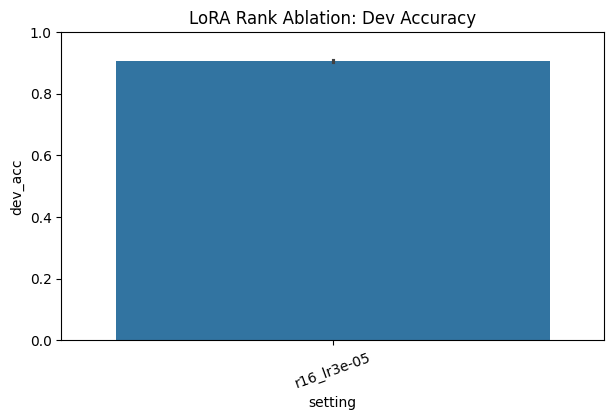

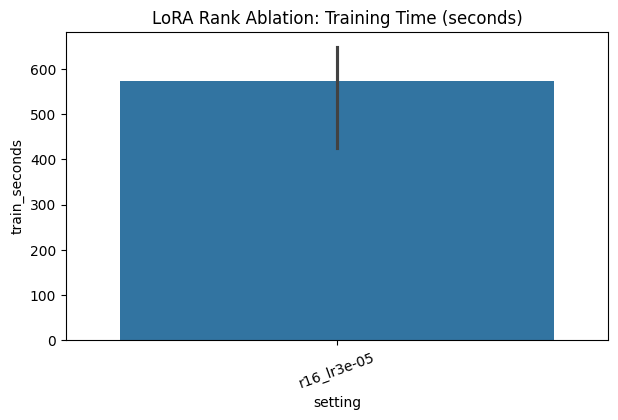

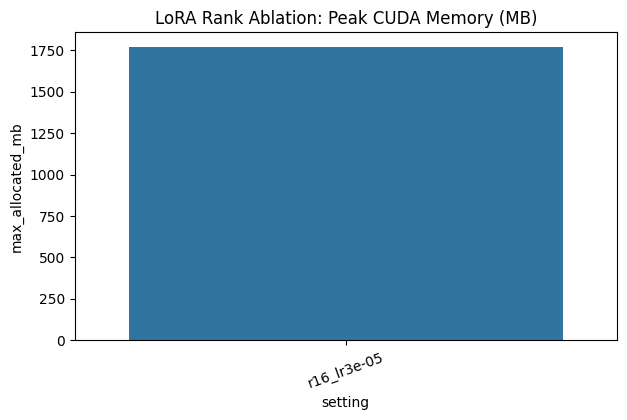

Ablation comparison (performance vs cost): Learning Rate Ablation


,group,setting,dev_acc,dev_f1,yelp_acc,imdb_acc,amazon_acc,ece_dev,train_seconds,max_allocated_mb,trainable_params
0,learning_rate,r8_lr2e-05,0.8968,0.8967,0.8740,0.8137,0.8707,0.0231,633.10,1751.12,1340930
1,learning_rate,r8_lr2e-05,0.8956,0.8955,0.8757,0.8156,0.8715,0.0153,672.64,1751.12,1340930
2,learning_rate,r8_lr2e-05,0.8991,0.8990,0.8749,0.8114,0.8711,0.0180,692.11,1751.12,1340930


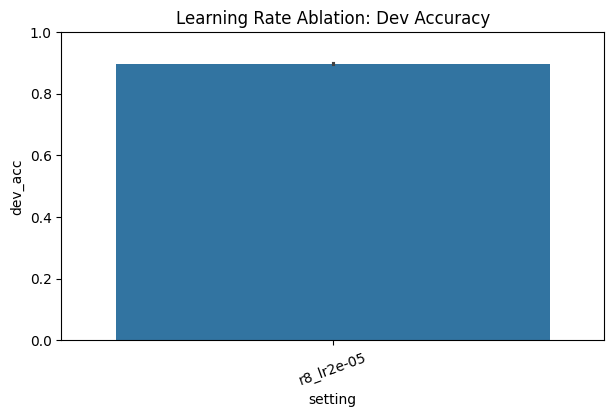

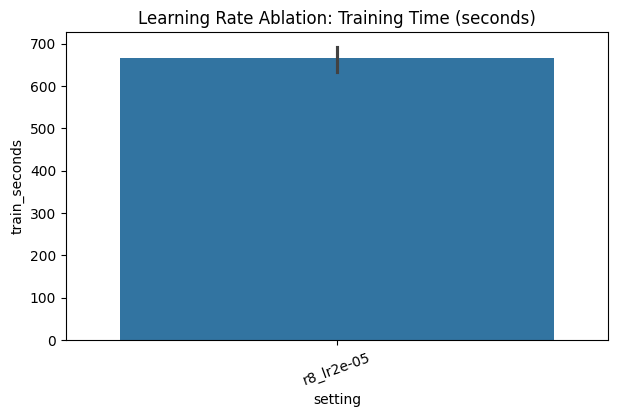

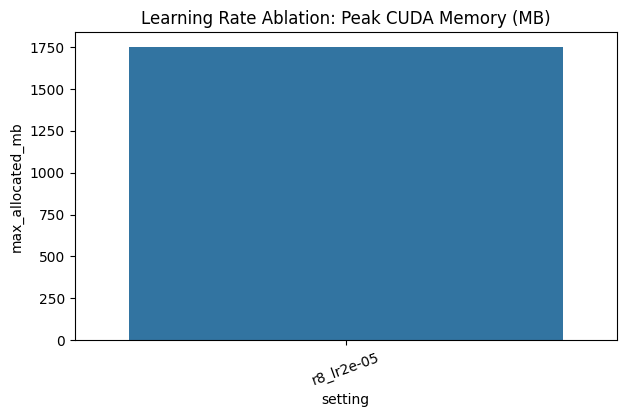

In [17]:
DEVELOPMENT = globals().get("DEVELOPMENT_MODE", True)

# Build views from the selected registry file and render baseline + ablation tables/plots
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DEFAULT_LORA_R = globals().get('BASELINE_LORA_R', 8)
DEFAULT_LR = float(globals().get('BASELINE_LR', globals().get('LEARNING_RATE', 3e-5)))

if not os.path.exists(REGISTRY_PATH):
    print(f"Registry not found at {REGISTRY_PATH}. Run the planner/executor first.")
else:
    with open(REGISTRY_PATH, 'r') as f:
        reg = json.load(f)
    entries = list(reg.values()) if isinstance(reg, dict) else []

    # -------- Baseline aggregation (mean over seeds per mode) --------
    buckets = {'full': {'dev': [], 'yelp': [], 'imdb': [], 'amazon': []},
               'lora': {'dev': [], 'yelp': [], 'imdb': [], 'amazon': []},
               'prompt': {'dev': [], 'yelp': [], 'imdb': [], 'amazon': []}}
    f1_dev = {'full': [], 'lora': [], 'prompt': []}

    for e in entries:
        if e.get('type') != 'baseline':
            continue
        m = e.get('mode')
        if m not in buckets:
            continue
        res = e.get('result', {})
        for split in ['dev','yelp','imdb','amazon']:
            if split in res and 'accuracy' in res[split]:
                buckets[m][split].append(float(res[split]['accuracy']))
        if 'dev' in res and 'f1_macro' in res['dev']:
            f1_dev[m].append(float(res['dev']['f1_macro']))

    name_map = {'full':'full_ft', 'lora':'peft_lora_r8', 'prompt':'prompt_tuning'}
    baseline_means = {}
    for m, splits in buckets.items():
        key = name_map[m]
        baseline_means[key] = {}
        for split, vals in splits.items():
            if vals:
                baseline_means[key][split] = {'accuracy': float(np.mean(vals))}
        if f1_dev[m]:
            baseline_means[key].setdefault('dev', {})['f1_macro'] = float(np.mean(f1_dev[m]))
    
    # -------- Baseline rendering --------
    baseline_rows = []

    for model_name, results in baseline_means.items():
        baseline_rows.append({
            "model": model_name,
            "dev_acc": results.get("dev", {}).get("accuracy", np.nan),
            "dev_f1": results.get("dev", {}).get("f1_macro", np.nan),
            "yelp_acc": results.get("yelp", {}).get("accuracy", np.nan),
            "imdb_acc": results.get("imdb", {}).get("accuracy", np.nan),
            "amazon_acc": results.get("amazon", {}).get("accuracy", np.nan),
        })

    baseline_df = pd.DataFrame(baseline_rows)

    if baseline_df.empty:
        print("No baseline rows found.")
    else:
        print("Baseline comparison")
        display(baseline_df.round(4))

    # -------- Ablations dataframe from registry --------
    rows = []
    for e in entries:
        if e.get('type') != 'ablation' or e.get('mode') != 'lora':
            continue
        res = e.get('result', {})
        lrr = e.get('lora_r')
        lr  = float(e.get('lr', np.nan))
        # classify
        if lrr is not None and int(lrr) != int(DEFAULT_LORA_R) and (np.isnan(lr) or lr == float(DEFAULT_LR)):
            group = 'lora_rank'
        elif lrr is not None and int(lrr) == int(DEFAULT_LORA_R) and not np.isnan(lr) and lr != float(DEFAULT_LR):
            group = 'learning_rate'
        else:
            group = 'combined'
        rows.append({
            'group': group,
            'setting': f"r{lrr if lrr is not None else 'n/a'}_lr{str(lr).replace('.', 'p') if not np.isnan(lr) else 'n/a'}",
            'dev_acc':   res.get('dev',{}).get('accuracy', np.nan),
            'dev_f1':    res.get('dev',{}).get('f1_macro', np.nan),
            'yelp_acc':  res.get('yelp',{}).get('accuracy', np.nan),
            'imdb_acc':  res.get('imdb',{}).get('accuracy', np.nan),
            'amazon_acc':res.get('amazon',{}).get('accuracy', np.nan),
            'ece_dev':   res.get('ece_dev', np.nan),
            'train_seconds': res.get('train_seconds', np.nan),
            'max_allocated_mb': (res.get('cuda_mem') or {}).get('max_allocated_mb', np.nan),
            'trainable_params': (res.get('params') or {}).get('trainable', np.nan),
        })
    ablations_df = pd.DataFrame(rows)

    # -------- Per-group rendering (tables + plots) --------
    def plot_group(df, title_suffix):
        if df.empty:
            print(f'Skipping {title_suffix}: no rows available.')
            return
        display_cols = [
            'group','setting','dev_acc','dev_f1','yelp_acc','imdb_acc','amazon_acc',
            'ece_dev','train_seconds','max_allocated_mb','trainable_params'
        ]
        disp = df[display_cols].copy()
        for c in ['dev_acc','dev_f1','yelp_acc','imdb_acc','amazon_acc','ece_dev']:
            disp[c] = disp[c].map(lambda x: round(float(x), 4) if pd.notna(x) else x)
        disp['train_seconds'] = disp['train_seconds'].map(lambda x: round(float(x), 2) if pd.notna(x) else x)
        disp['max_allocated_mb'] = disp['max_allocated_mb'].map(lambda x: round(float(x), 2) if pd.notna(x) else x)

        print(f'Ablation comparison (performance vs cost): {title_suffix}')
        display(disp.sort_values('setting').reset_index(drop=True))

        plt.figure(figsize=(7,4))
        sns.barplot(data=disp, x='setting', y='dev_acc')
        plt.title(f'{title_suffix}: Dev Accuracy')
        plt.ylim(0,1.0); plt.xticks(rotation=20); plt.show()

        plt.figure(figsize=(7,4))
        sns.barplot(data=disp, x='setting', y='train_seconds')
        plt.title(f'{title_suffix}: Training Time (seconds)')
        plt.xticks(rotation=20); plt.show()

        plt.figure(figsize=(7,4))
        sns.barplot(data=disp, x='setting', y='max_allocated_mb')
        plt.title(f'{title_suffix}: Peak CUDA Memory (MB)')
        plt.xticks(rotation=20); plt.show()

    # Explicit group splits
    # Guard: if still empty or missing 'group', stop gracefully
# -------- Development fallback when ablations have not been run --------
if ablations_df.empty or 'group' not in ablations_df.columns:
    print(f"No ablation rows found in {REGISTRY_FILENAME}.")

    if DEVELOPMENT:
        print('DEVELOPMENT=True, so using the LoRA baseline as a placeholder ablation row.')

        dev_rows = []

        for e in entries:
            if e.get('type') == 'baseline' and e.get('mode') == 'lora':
                res = e.get('result', {})
                lrr = e.get('lora_r', DEFAULT_LORA_R)
                lr = float(e.get('lr', DEFAULT_LR))

                dev_rows.append({
                    'group': 'lora_rank',
                    'setting': f"baseline_r{lrr}_lr{str(lr).replace('.', 'p')}",
                    'dev_acc': res.get('dev', {}).get('accuracy', np.nan),
                    'dev_f1': res.get('dev', {}).get('f1_macro', np.nan),
                    'yelp_acc': res.get('yelp', {}).get('accuracy', np.nan),
                    'imdb_acc': res.get('imdb', {}).get('accuracy', np.nan),
                    'amazon_acc': res.get('amazon', {}).get('accuracy', np.nan),
                    'ece_dev': res.get('ece_dev', np.nan),
                    'train_seconds': res.get('train_seconds', np.nan),
                    'max_allocated_mb': (res.get('cuda_mem') or {}).get('max_allocated_mb', np.nan),
                    'trainable_params': (res.get('params') or {}).get('trainable', np.nan),
                })

        ablations_df = pd.DataFrame(dev_rows)

        if ablations_df.empty:
            print('No LoRA baseline found either, so ablation plots are skipped.')
        else:
            lora_rank_df = ablations_df[ablations_df['group'] == 'lora_rank'].copy()
            learning_rate_df = ablations_df[ablations_df['group'] == 'learning_rate'].copy()

            plot_group(lora_rank_df, 'LoRA Rank Ablation - Development Placeholder')
            plot_group(learning_rate_df, 'Learning Rate Ablation - Development Placeholder')
    else:
        print('Skipping ablation plots because DEVELOPMENT=False.')
else:
    lora_rank_df = ablations_df[ablations_df['group'] == 'lora_rank'].copy()
    learning_rate_df = ablations_df[ablations_df['group'] == 'learning_rate'].copy()

    plot_group(lora_rank_df, 'LoRA Rank Ablation')
    plot_group(learning_rate_df, 'Learning Rate Ablation')

## Visual Cross-Domain Comparison

These plots make the domain-shift pattern easier to inspect. They show how each method performs on SST-2 and then on Yelp, IMDB, and Amazon.

The key observation from the final results is that full fine-tuning has the highest absolute cross-domain accuracy, while LoRA has a smaller generalization gap relative to its SST-2 performance.


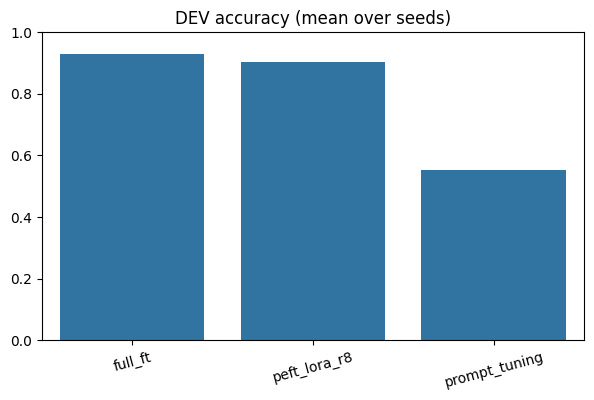

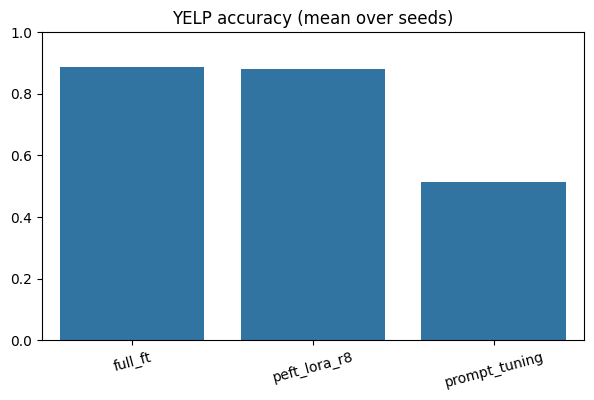

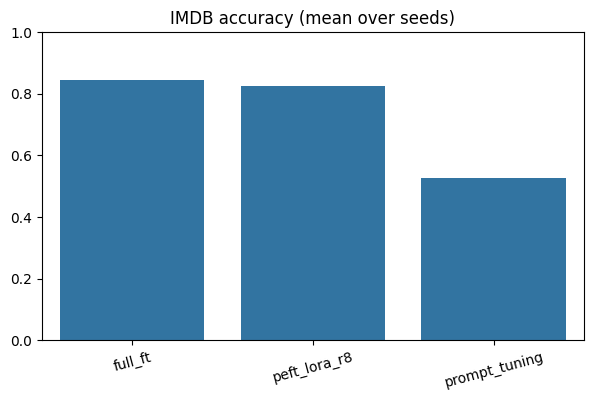

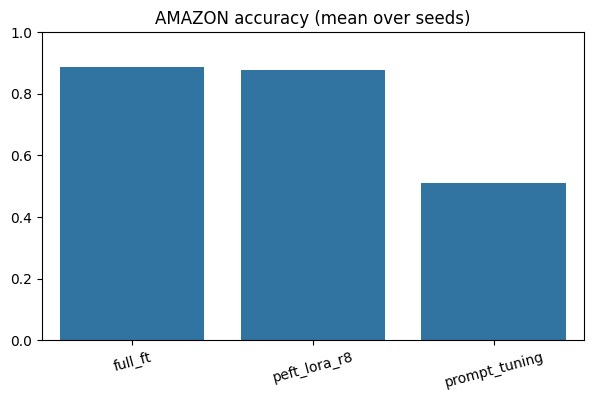

In [18]:
# Plotting from baseline_means (built from the selected registry file)
import matplotlib.pyplot as plt
import seaborn as sns

def plot_bar_from_baseline_means(split: str, metric: str = 'accuracy'):
    if 'baseline_means' not in globals() or not baseline_means:
        print('Run the registry view builder cell first to populate baseline_means.')
        return
    names, vals = [], []
    for model_name, splits in baseline_means.items():
        if split in splits and metric in splits[split]:
            names.append(model_name)
            vals.append(splits[split][metric])
    if not names:
        print(f'No data to plot for split={split}, metric={metric}')
        return
    plt.figure(figsize=(7,4))
    sns.barplot(x=names, y=vals)
    plt.title(f'{split.upper()} {metric} (mean over seeds)')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=15)
    plt.show()

plot_bar_from_baseline_means('dev', 'accuracy')
plot_bar_from_baseline_means('yelp', 'accuracy')
plot_bar_from_baseline_means('imdb', 'accuracy')
plot_bar_from_baseline_means('amazon', 'accuracy')

## LoRA Ablation Analysis

This cell analyzes whether changing LoRA rank or learning rate improves the performance-efficiency trade-off.

The final result showed that increasing rank from `8` to `16` roughly doubled trainable parameters, but only slightly improved accuracy. That makes `r=8` the better efficiency balance in this experiment.


Ablation comparison (mean over seeds from results_registry_full.json):


,group,setting,dev_acc,dev_f1,yelp_acc,imdb_acc,amazon_acc,ece_dev,train_seconds,max_allocated_mb,trainable_params
0,combined,r16_lr2e-05,0.9006,0.9005,0.8784,0.8226,0.8765,0.0151,640.27,1771.22,2680322.0
1,learning_rate,r8_lr2e-05,0.8972,0.8971,0.8749,0.8135,0.8711,0.0188,665.95,1751.12,1340930.0
2,lora_rank,r16_lr3e-05,0.9052,0.9051,0.8796,0.8266,0.8788,0.0204,572.71,1771.22,2680322.0


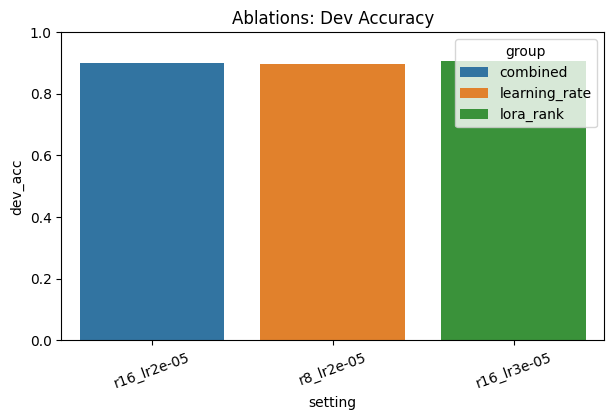

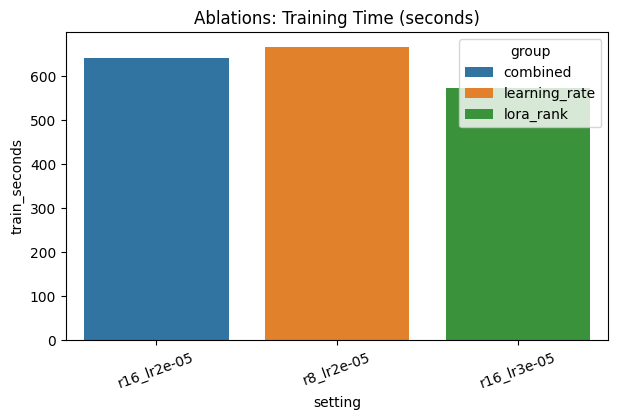

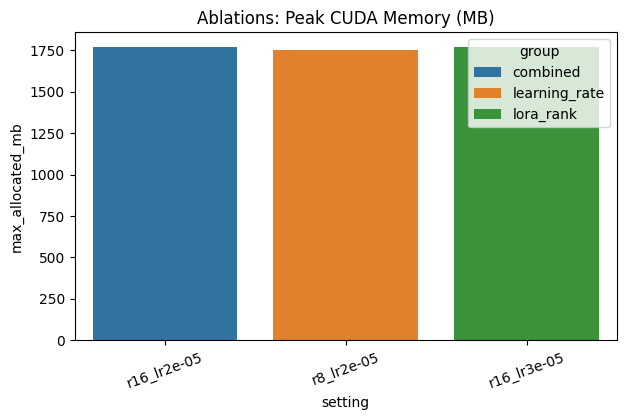

In [19]:
# Ablation comparison table (performance vs cost) from the selected registry file

import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DEFAULT_LORA_R = globals().get('BASELINE_LORA_R', 8)
DEFAULT_LR = float(globals().get('BASELINE_LR', globals().get('LEARNING_RATE', 3e-5)))

def classify_lora_ablation(lora_r, lr):
    rank_changed = lora_r is not None and int(lora_r) != int(DEFAULT_LORA_R)
    lr_changed = pd.notna(lr) and float(lr) != float(DEFAULT_LR)
    if rank_changed and not lr_changed:
        return 'lora_rank'
    if lr_changed and not rank_changed:
        return 'learning_rate'
    return 'combined'

if not os.path.exists(REGISTRY_PATH):
    print(f"Registry not found at {REGISTRY_PATH}. Run the planner/executor first.")
else:
    with open(REGISTRY_PATH, 'r') as f:
        reg = json.load(f)
    entries = list(reg.values()) if isinstance(reg, dict) else []

    rows = []
    for e in entries:
        if e.get('type') != 'ablation' or e.get('mode') != 'lora':
            continue
        metrics = e.get('result', {}) or {}
        lora_r = e.get('lora_r')
        lr = float(e.get('lr', np.nan))
        rows.append({
            'group': classify_lora_ablation(lora_r, lr),
            'setting': f"r{lora_r if lora_r is not None else 'n/a'}_lr{str(lr).replace('.', 'p') if pd.notna(lr) else 'n/a'}",
            'seed': e.get('seed'),
            'lora_r': lora_r,
            'lr': lr,
            'dev_acc': metrics.get('dev', {}).get('accuracy', np.nan),
            'dev_f1': metrics.get('dev', {}).get('f1_macro', np.nan),
            'yelp_acc': metrics.get('yelp', {}).get('accuracy', np.nan),
            'imdb_acc': metrics.get('imdb', {}).get('accuracy', np.nan),
            'amazon_acc': metrics.get('amazon', {}).get('accuracy', np.nan),
            'ece_dev': metrics.get('ece_dev', np.nan),
            'train_seconds': metrics.get('train_seconds', np.nan),
            'max_allocated_mb': (metrics.get('cuda_mem') or {}).get('max_allocated_mb', np.nan),
            'trainable_params': (metrics.get('params') or {}).get('trainable', np.nan),
            'total_params': (metrics.get('params') or {}).get('total', np.nan),
        })

    ablation_df = pd.DataFrame(rows)

    # Development fallback: use LoRA baseline as placeholder when ablations are missing
    if ablation_df.empty and DEVELOPMENT:
        print(f"No ablation rows found in {REGISTRY_FILENAME}.")
        print('DEVELOPMENT=True, so using LoRA baseline as a placeholder ablation row.')

        dev_rows = []

        for e in entries:
            if e.get('type') == 'baseline' and e.get('mode') == 'lora':
                metrics = e.get('result', {}) or {}
                lora_r = e.get('lora_r', DEFAULT_LORA_R)
                lr = float(e.get('lr', DEFAULT_LR))

                dev_rows.append({
                    'group': 'development_placeholder',
                    'setting': f"baseline_r{lora_r}_lr{str(lr).replace('.', 'p')}",
                    'seed': e.get('seed'),
                    'lora_r': lora_r,
                    'lr': lr,
                    'dev_acc': metrics.get('dev', {}).get('accuracy', np.nan),
                    'dev_f1': metrics.get('dev', {}).get('f1_macro', np.nan),
                    'yelp_acc': metrics.get('yelp', {}).get('accuracy', np.nan),
                    'imdb_acc': metrics.get('imdb', {}).get('accuracy', np.nan),
                    'amazon_acc': metrics.get('amazon', {}).get('accuracy', np.nan),
                    'ece_dev': metrics.get('ece_dev', np.nan),
                    'train_seconds': metrics.get('train_seconds', np.nan),
                    'max_allocated_mb': (metrics.get('cuda_mem') or {}).get('max_allocated_mb', np.nan),
                    'trainable_params': (metrics.get('params') or {}).get('trainable', np.nan),
                    'total_params': (metrics.get('params') or {}).get('total', np.nan),
                })

        ablation_df = pd.DataFrame(dev_rows)

    if ablation_df.empty:
        print('No ablation rows found and no LoRA baseline placeholder available.')
    else:
        metric_cols = ['dev_acc', 'dev_f1', 'yelp_acc', 'imdb_acc', 'amazon_acc', 'ece_dev']
        mean_cols = metric_cols + ['train_seconds', 'max_allocated_mb', 'trainable_params', 'total_params']
        summary_df = (
            ablation_df
            .groupby(['group', 'setting', 'lora_r', 'lr'], dropna=False)[mean_cols]
            .mean(numeric_only=True)
            .reset_index()
        )

        display_cols = [
            'group', 'setting', 'dev_acc', 'dev_f1', 'yelp_acc', 'imdb_acc', 'amazon_acc',
            'ece_dev', 'train_seconds', 'max_allocated_mb', 'trainable_params'
        ]
        display_df = summary_df[display_cols].copy()
        for c in metric_cols:
            display_df[c] = display_df[c].map(lambda x: round(float(x), 4) if pd.notna(x) else x)
        display_df['train_seconds'] = display_df['train_seconds'].map(lambda x: round(float(x), 2) if pd.notna(x) else x)
        display_df['max_allocated_mb'] = display_df['max_allocated_mb'].map(lambda x: round(float(x), 2) if pd.notna(x) else x)

        print(f"Ablation comparison (mean over seeds from {REGISTRY_FILENAME}):")
        display(display_df.sort_values(['group', 'setting']).reset_index(drop=True))

        for y_col, title in [
            ('dev_acc', 'Ablations: Dev Accuracy'),
            ('train_seconds', 'Ablations: Training Time (seconds)'),
            ('max_allocated_mb', 'Ablations: Peak CUDA Memory (MB)'),
        ]:
            plot_df = display_df.dropna(subset=[y_col])
            if plot_df.empty:
                print(f'No {y_col} values available to plot.')
                continue
            plt.figure(figsize=(7,4))
            sns.barplot(data=plot_df, x='setting', y=y_col, hue='group')
            plt.title(title)
            if y_col == 'dev_acc':
                plt.ylim(0, 1.0)
            plt.xticks(rotation=20)
            plt.show()

## Tuned Prompt Interpretation

The tuned prompt runs are reported separately because they use a prompt-specific hyperparameter regime. They show that prompt-tuning is highly sensitive to learning rate, training duration, and number of virtual tokens.

The main fair comparison remains the shared setup: full fine-tuning vs LoRA vs baseline prompt-tuning.


## Final Results Analysis

The remaining cells load the completed full registry and produce the report-ready analysis. This is the part to use when walking through what was observed after all planned runs finished.

The analysis is organized around five questions:

1. Which method performs best in-domain?
2. Which method transfers best to Yelp, IMDB, and Amazon?
3. Which method is most robust to perturbations?
4. Which method is best calibrated?
5. Which method gives the best performance-efficiency trade-off?


## Final Multi-Seed Results Analysis

These cells analyze the completed experiment grid from `outputs/results_registry_full.json`. They aggregate each method/configuration across seeds `7`, `42`, and `2026`, then compute cross-domain generalization, robustness drops, calibration metrics, and computational efficiency for the final report.


## Loading the Final Registry

This cell flattens `outputs/results_registry_full.json` into a table where each row is one completed run. It computes derived metrics such as average cross-domain accuracy, average cross-domain F1, and the generalization gap.

The final analysis uses means and standard deviations across seeds `7`, `42`, and `2026`, which makes the conclusions more reliable than a single run.


In [3]:
# Final results analysis from the full multi-seed registry
import os, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FULL_REGISTRY_PATH = os.path.join('outputs', 'results_registry_full.json')
PLANNED_SEEDS = [7, 42, 2026]
DOMAINS = ['yelp', 'imdb', 'amazon']
ROBUST_SPLITS = {
    'punctuation': 'robust_dev_punctuation',
    'char_noise': 'robust_dev_char_noise',
    'synonym': 'robust_dev_synonym',
}


def _nested(metrics, *keys, default=np.nan):
    cur = metrics
    for key in keys:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def _method_label(entry):
    if entry.get('type') == 'baseline':
        return {
            'full': 'full_ft',
            'lora': f"peft_lora_r{entry.get('lora_r', globals().get('BASELINE_LORA_R', 8))}",
            'prompt': 'prompt_tuning',
        }.get(entry.get('mode'), entry.get('mode', 'unknown'))
    if entry.get('type') == 'exploratory_prompt' and entry.get('mode') == 'prompt':
        return f"prompt_tuned_exploratory_vtokens{entry.get('num_virtual_tokens')}"
    if entry.get('mode') == 'lora':
        lr = entry.get('lr', np.nan)
        lr_label = 'na' if pd.isna(lr) else f"{float(lr):.0e}"
        return f"lora_r{entry.get('lora_r', 'na')}_lr{lr_label}"
    return f"{entry.get('mode', 'unknown')}_{entry.get('type', 'run')}"


def flatten_registry(registry):
    rows = []
    entries = registry.items() if isinstance(registry, dict) else enumerate(registry)

    for run_key, entry in entries:
        metrics = entry.get('result', {}) or {}
        yelp_acc = _nested(metrics, 'yelp', 'accuracy')
        imdb_acc = _nested(metrics, 'imdb', 'accuracy')
        amazon_acc = _nested(metrics, 'amazon', 'accuracy')
        yelp_f1 = _nested(metrics, 'yelp', 'f1_macro')
        imdb_f1 = _nested(metrics, 'imdb', 'f1_macro')
        amazon_f1 = _nested(metrics, 'amazon', 'f1_macro')
        cross_acc = np.nanmean([yelp_acc, imdb_acc, amazon_acc])
        cross_f1 = np.nanmean([yelp_f1, imdb_f1, amazon_f1])
        dev_acc = _nested(metrics, 'dev', 'accuracy')
        dev_f1 = _nested(metrics, 'dev', 'f1_macro')

        row = {
            'run_key': run_key,
            'run_type': entry.get('type'),
            'mode': entry.get('mode'),
            'method': _method_label(entry),
            'seed': entry.get('seed'),
            'lora_r': entry.get('lora_r'),
            'lr': entry.get('lr'),
            'num_virtual_tokens': entry.get('num_virtual_tokens'),
            'dev_accuracy': dev_acc,
            'dev_f1_macro': dev_f1,
            'yelp_accuracy': yelp_acc,
            'yelp_f1_macro': yelp_f1,
            'imdb_accuracy': imdb_acc,
            'imdb_f1_macro': imdb_f1,
            'amazon_accuracy': amazon_acc,
            'amazon_f1_macro': amazon_f1,
            'cross_domain_avg_accuracy': cross_acc,
            'cross_domain_avg_f1': cross_f1,
            'generalization_gap': dev_acc - cross_acc,
            'ece_dev': metrics.get('ece_dev', np.nan),
            'temp': metrics.get('temp', np.nan),
            'params_total': _nested(metrics, 'params', 'total'),
            'params_trainable': _nested(metrics, 'params', 'trainable'),
            'train_seconds': metrics.get('train_seconds', np.nan),
            'cuda_max_allocated_mb': _nested(metrics, 'cuda_mem', 'max_allocated_mb'),
            'cuda_reserved_mb': _nested(metrics, 'cuda_mem', 'reserved_mb'),
        }

        for label, split in ROBUST_SPLITS.items():
            robust_acc = _nested(metrics, split, 'accuracy')
            robust_f1 = _nested(metrics, split, 'f1_macro')
            row[f'robust_{label}_accuracy'] = robust_acc
            row[f'robust_{label}_f1_macro'] = robust_f1
            row[f'{label}_accuracy_drop'] = dev_acc - robust_acc
            row[f'{label}_f1_drop'] = dev_f1 - robust_f1

        rows.append(row)

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df[df['seed'].isin(PLANNED_SEEDS)].copy()
        df['params_trainable_pct'] = 100 * df['params_trainable'] / df['params_total']
    return df


def summarize_mean_std(df, group_cols, metric_cols):
    summary = df.groupby(group_cols, dropna=False)[metric_cols].agg(['mean', 'std', 'count']).reset_index()
    summary.columns = ['_'.join([str(part) for part in col if part]) for col in summary.columns.to_flat_index()]
    return summary


def fmt_mean_std(summary, group_cols, metric_cols, decimals=4):
    rows = []
    for _, row in summary.iterrows():
        out = {col: row[col] for col in group_cols}
        seed_count = int(max([row.get(f'{metric}_count', 0) for metric in metric_cols] or [0]))
        out['n_seeds'] = seed_count
        for metric in metric_cols:
            mean = row.get(f'{metric}_mean', np.nan)
            std = row.get(f'{metric}_std', np.nan)
            if pd.isna(mean):
                out[metric] = np.nan
            else:
                std = 0.0 if pd.isna(std) else std
                out[metric] = f"{mean:.{decimals}f} +/- {std:.{decimals}f}"
        rows.append(out)
    return pd.DataFrame(rows)

if not os.path.exists(FULL_REGISTRY_PATH):
    print(f"Full registry not found: {FULL_REGISTRY_PATH}")
    print('Run the full experiment grid first, then re-run this analysis cell.')
else:
    with open(FULL_REGISTRY_PATH, 'r') as f:
        full_registry = json.load(f)

    final_runs_df = flatten_registry(full_registry)
    if final_runs_df.empty:
        print(f'No runs for planned seeds {PLANNED_SEEDS} found in {FULL_REGISTRY_PATH}.')
    else:
        present = sorted(final_runs_df['seed'].dropna().astype(int).unique().tolist())
        missing = sorted(set(PLANNED_SEEDS) - set(present))
        print(f'Loaded {len(final_runs_df)} runs from {FULL_REGISTRY_PATH}. Seeds present: {present}')
        if missing:
            print(f'Warning: planned seeds missing from registry: {missing}')

        display(final_runs_df[['run_key', 'run_type', 'method', 'seed', 'dev_accuracy', 'cross_domain_avg_accuracy', 'generalization_gap', 'ece_dev', 'params_trainable', 'train_seconds']])


Loaded 24 runs from outputs\results_registry_full.json. Seeds present: [7, 42, 2026]


,run_key,run_type,method,seed,dev_accuracy,cross_domain_avg_accuracy,generalization_gap,ece_dev,params_trainable,train_seconds
0,full_seed7,baseline,full_ft,7,0.931193,0.876099,0.055094,0.049289,109483778,515.15
1,full_seed42,baseline,full_ft,42,0.932339,0.868034,0.064306,0.041873,109483778,515.78
2,full_seed2026,baseline,full_ft,2026,0.923165,0.871857,0.051308,0.049380,109483778,513.40
3,prompt_seed7,baseline,prompt_tuning,7,0.510321,0.501021,0.009300,0.173735,16898,449.86
4,prompt_seed42,baseline,prompt_tuning,42,0.623853,0.546713,0.077141,0.036200,16898,439.52
5,prompt_seed2026,baseline,prompt_tuning,2026,0.526376,0.503394,0.022982,0.072385,16898,436.49
6,lora_seed7_r8,baseline,peft_lora_r8,7,0.902523,0.859576,0.042946,0.013285,1340930,637.02
7,lora_seed42_r8,baseline,peft_lora_r8,42,0.905963,0.861450,0.044514,0.009424,1340930,638.53
8,lora_seed2026_r8,baseline,peft_lora_r8,2026,0.902523,0.861838,0.040685,0.019898,1340930,634.00
9,lora_seed7_r8_lr2e-05,ablation,lora_r8_lr2e-05,7,0.896789,0.852786,0.044003,0.023108,1340930,633.10


## Final Tables and Plots

This cell produces the main evidence for the final analysis:

- Cross-domain generalization tables.
- Per-domain accuracy and F1.
- Robustness drops under punctuation, character noise, and synonym replacement.
- Calibration and temperature scaling results.
- Efficiency metrics such as trainable parameters, training time, and CUDA memory.
- LoRA ablation summaries.

The final observed pattern was: full fine-tuning reached the best raw accuracy, LoRA gave the strongest performance-efficiency trade-off and best calibration, and prompt-tuning required prompt-specific tuning to become competitive enough to discuss as an ultra-lightweight alternative.


Cross-domain generalization (mean +/- std over seeds)


,run_type,method,mode,n_seeds,dev_accuracy,dev_f1_macro,cross_domain_avg_accuracy,cross_domain_avg_f1,generalization_gap
0,baseline,full_ft,full,3,0.9289 +/- 0.0050,0.9289 +/- 0.0050,0.8720 +/- 0.0040,0.8718 +/- 0.0042,0.0569 +/- 0.0067
1,baseline,peft_lora_r8,lora,3,0.9037 +/- 0.0020,0.9036 +/- 0.0020,0.8610 +/- 0.0012,0.8608 +/- 0.0013,0.0427 +/- 0.0019
2,exploratory_prompt,prompt_tuned_exploratory_vtokens20,prompt,3,0.8486 +/- 0.0072,0.8482 +/- 0.0071,0.7804 +/- 0.0121,0.7799 +/- 0.0123,0.0683 +/- 0.0179
3,exploratory_prompt,prompt_tuned_exploratory_vtokens30,prompt,3,0.8490 +/- 0.0151,0.8487 +/- 0.0151,0.7974 +/- 0.0131,0.7971 +/- 0.0133,0.0516 +/- 0.0114
4,baseline,prompt_tuning,prompt,3,0.5535 +/- 0.0614,0.4521 +/- 0.1418,0.5170 +/- 0.0257,0.3971 +/- 0.0952,0.0365 +/- 0.0359


Per-domain accuracy/F1 (mean +/- std over seeds)


,run_type,method,mode,n_seeds,yelp_accuracy,yelp_f1_macro,imdb_accuracy,imdb_f1_macro,amazon_accuracy,amazon_f1_macro
0,baseline,full_ft,full,3,0.8855 +/- 0.0025,0.8855 +/- 0.0026,0.8440 +/- 0.0045,0.8438 +/- 0.0047,0.8865 +/- 0.0053,0.8862 +/- 0.0055
1,baseline,peft_lora_r8,lora,3,0.8806 +/- 0.0012,0.8806 +/- 0.0012,0.8240 +/- 0.0014,0.8236 +/- 0.0016,0.8783 +/- 0.0016,0.8781 +/- 0.0017
2,exploratory_prompt,prompt_tuned_exploratory_vtokens20,prompt,3,0.8064 +/- 0.0127,0.8063 +/- 0.0126,0.7243 +/- 0.0152,0.7232 +/- 0.0157,0.8105 +/- 0.0086,0.8102 +/- 0.0087
3,exploratory_prompt,prompt_tuned_exploratory_vtokens30,prompt,3,0.8218 +/- 0.0162,0.8217 +/- 0.0162,0.7513 +/- 0.0175,0.7506 +/- 0.0182,0.8191 +/- 0.0106,0.8190 +/- 0.0105
4,baseline,prompt_tuning,prompt,3,0.5141 +/- 0.0191,0.3912 +/- 0.0766,0.5276 +/- 0.0454,0.4168 +/- 0.1352,0.5094 +/- 0.0127,0.3832 +/- 0.0740


Robustness drops vs clean SST-2 dev accuracy (lower is better)


...

,run_type,method,mode,n_seeds,ece_dev,temp
0,baseline,full_ft,full,3,0.0468 +/- 0.0043,4.7333 +/- 0.1155
1,baseline,peft_lora_r8,lora,3,0.0142 +/- 0.0053,1.4000 +/- 0.0000
2,exploratory_prompt,prompt_tuned_exploratory_vtokens20,prompt,3,0.0277 +/- 0.0055,1.3667 +/- 0.0577
3,exploratory_prompt,prompt_tuned_exploratory_vtokens30,prompt,3,0.0234 +/- 0.0065,1.4000 +/- 0.0000
4,baseline,prompt_tuning,prompt,3,0.0941 +/- 0.0713,0.8667 +/- 0.3215


Computational efficiency (means over seeds, plus reduction relative to full fine-tuning)


,run_type,method,mode,params_trainable_mean,params_trainable_std,params_trainable_pct_mean,train_seconds_mean,train_seconds_std,cuda_max_allocated_mb_mean,cuda_max_allocated_mb_std,trainable_param_reduction_vs_full,training_time_saved_vs_full_sec,cuda_memory_saved_vs_full_mb
0,baseline,full_ft,full,109483778.0,0.0,100.0000,514.7767,1.2331,2365.1267,9.3069,1.0000,0.0000,0.0000
1,baseline,peft_lora_r8,lora,1340930.0,0.0,1.2100,636.5167,2.3066,1751.1200,0.0000,81.6476,-121.7400,614.0067
2,exploratory_prompt,prompt_tuned_exploratory_vtokens20,prompt,16898.0,0.0,0.0154,326.5567,0.3308,1292.8567,0.6120,6479.0968,188.2200,1072.2700
3,exploratory_prompt,prompt_tuned_exploratory_vtokens30,prompt,24578.0,0.0,0.0224,325.4500,1.0516,1339.0800,0.0000,4454.5438,189.3267,1026.0467
4,baseline,prompt_tuning,prompt,16898.0,0.0,0.0154,441.9567,7.0102,1297.2100,0.0000,6479.0968,72.8200,1067.9167


LoRA ablation analysis (mean +/- std over seeds)


,run_type,method,mode,lora_r,lr,n_seeds,dev_accuracy,dev_f1_macro,cross_domain_avg_accuracy,cross_domain_avg_f1,punctuation_accuracy_drop,char_noise_accuracy_drop,synonym_accuracy_drop,ece_dev,params_trainable,train_seconds,cuda_max_allocated_mb
0,ablation,lora_r8_lr2e-05,lora,8,0.00002,3,0.8972 +/- 0.0018,0.8971 +/- 0.0018,0.8532 +/- 0.0010,0.8529 +/- 0.0010,0.0138 +/- 0.0023,0.0409 +/- 0.0018,0.0000 +/- 0.0000,0.0188 +/- 0.0040,1340930.0000 +/- 0.0000,665.9500 +/- 30.0685,1751.1200 +/- 0.0000
1,ablation,lora_r16_lr2e-05,lora,16,0.00002,3,0.9006 +/- 0.0018,0.9005 +/- 0.0018,0.8592 +/- 0.0014,0.8590 +/- 0.0015,0.0115 +/- 0.0040,0.0382 +/- 0.0070,0.0004 +/- 0.0007,0.0151 +/- 0.0025,2680322.0000 +/- 0.0000,640.2667 +/- 2.5796,1771.2200 +/- 0.0000
2,ablation,lora_r16_lr3e-05,lora,16,0.00003,3,0.9052 +/- 0.0037,0.9051 +/- 0.0037,0.8617 +/- 0.0042,0.8616 +/- 0.0041,0.0141 +/- 0.0013,0.0363 +/- 0.0052,0.0004 +/- 0.0007,0.0204 +/- 0.0052,2680322.0000 +/- 0.0000,572.7100 +/- 126.6312,1771.2200 +/- 0.0000


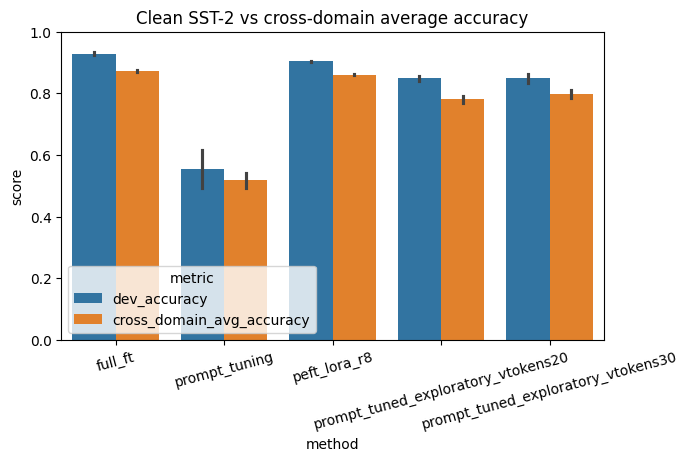

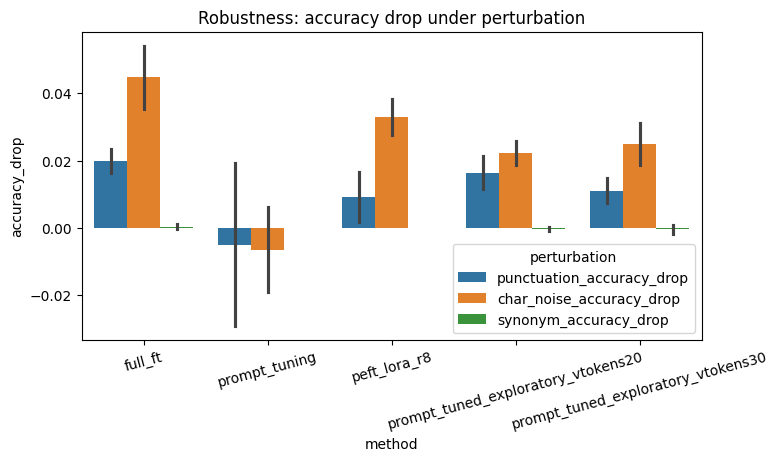

In [4]:
# Final report tables: generalization, robustness, calibration, efficiency, and ablations
def barplot_with_sd(*args, **kwargs):
    try:
        return sns.barplot(*args, errorbar='sd', **kwargs)
    except TypeError:
        return sns.barplot(*args, ci='sd', **kwargs)

if 'final_runs_df' not in globals() or final_runs_df.empty:
    print('Run the final registry loading cell first.')
else:
    baseline_df = final_runs_df[final_runs_df['run_type'].eq('baseline')].copy()
    exploratory_prompt_df = final_runs_df[
        final_runs_df['run_type'].eq('exploratory_prompt') & final_runs_df['mode'].eq('prompt')
    ].copy()
    comparison_df = pd.concat([baseline_df, exploratory_prompt_df], ignore_index=True)
    ablation_df = final_runs_df[final_runs_df['run_type'].eq('ablation')].copy()

    baseline_group_cols = ['run_type', 'method', 'mode']
    baseline_metrics = [
        'dev_accuracy', 'dev_f1_macro',
        'yelp_accuracy', 'yelp_f1_macro', 'imdb_accuracy', 'imdb_f1_macro', 'amazon_accuracy', 'amazon_f1_macro',
        'cross_domain_avg_accuracy', 'cross_domain_avg_f1', 'generalization_gap',
        'punctuation_accuracy_drop', 'char_noise_accuracy_drop', 'synonym_accuracy_drop',
        'ece_dev', 'temp', 'params_trainable', 'params_trainable_pct',
        'train_seconds', 'cuda_max_allocated_mb', 'cuda_reserved_mb',
    ]

    if comparison_df.empty:
        print('No baseline or exploratory prompt rows found in the full registry.')
    else:
        comparison_group_cols = ['run_type', 'method', 'mode']
        comparison_summary = summarize_mean_std(comparison_df, comparison_group_cols, baseline_metrics)

        print('Cross-domain generalization (mean +/- std over seeds)')
        display(fmt_mean_std(
            comparison_summary,
            comparison_group_cols,
            ['dev_accuracy', 'dev_f1_macro', 'cross_domain_avg_accuracy', 'cross_domain_avg_f1', 'generalization_gap']
        ).sort_values('method').reset_index(drop=True))

        print('Per-domain accuracy/F1 (mean +/- std over seeds)')
        display(fmt_mean_std(
            comparison_summary,
            comparison_group_cols,
            ['yelp_accuracy', 'yelp_f1_macro', 'imdb_accuracy', 'imdb_f1_macro', 'amazon_accuracy', 'amazon_f1_macro']
        ).sort_values('method').reset_index(drop=True))

        print('Robustness drops vs clean SST-2 dev accuracy (lower is better)')
        display(fmt_mean_std(
            comparison_summary,
            comparison_group_cols,
            ['punctuation_accuracy_drop', 'char_noise_accuracy_drop', 'synonym_accuracy_drop']
        ).sort_values('method').reset_index(drop=True))

        print('Calibration after temperature scaling (lower ECE is better)')
        display(fmt_mean_std(
            comparison_summary,
            comparison_group_cols,
            ['ece_dev', 'temp']
        ).sort_values('method').reset_index(drop=True))

        efficiency = comparison_summary[[
            'run_type', 'method', 'mode',
            'params_trainable_mean', 'params_trainable_std', 'params_trainable_pct_mean',
            'train_seconds_mean', 'train_seconds_std',
            'cuda_max_allocated_mb_mean', 'cuda_max_allocated_mb_std',
        ]].copy()
        full_trainable = efficiency.loc[efficiency['mode'].eq('full'), 'params_trainable_mean']
        full_time = efficiency.loc[efficiency['mode'].eq('full'), 'train_seconds_mean']
        full_mem = efficiency.loc[efficiency['mode'].eq('full'), 'cuda_max_allocated_mb_mean']
        if not full_trainable.empty:
            efficiency['trainable_param_reduction_vs_full'] = full_trainable.iloc[0] / efficiency['params_trainable_mean']
        if not full_time.empty:
            efficiency['training_time_saved_vs_full_sec'] = full_time.iloc[0] - efficiency['train_seconds_mean']
        if not full_mem.empty:
            efficiency['cuda_memory_saved_vs_full_mb'] = full_mem.iloc[0] - efficiency['cuda_max_allocated_mb_mean']

        for col in efficiency.select_dtypes(include='number').columns:
            efficiency[col] = efficiency[col].map(lambda x: round(float(x), 4) if pd.notna(x) else x)
        print('Computational efficiency (means over seeds, plus reduction relative to full fine-tuning)')
        display(efficiency.sort_values('method').reset_index(drop=True))

    if ablation_df.empty:
        print('No LoRA ablation rows found in the full registry.')
    else:
        ablation_group_cols = ['run_type', 'method', 'mode', 'lora_r', 'lr']
        ablation_metrics = [
            'dev_accuracy', 'dev_f1_macro', 'cross_domain_avg_accuracy', 'cross_domain_avg_f1',
            'punctuation_accuracy_drop', 'char_noise_accuracy_drop', 'synonym_accuracy_drop',
            'ece_dev', 'params_trainable', 'train_seconds', 'cuda_max_allocated_mb',
        ]
        ablation_summary = summarize_mean_std(ablation_df, ablation_group_cols, ablation_metrics)
        print('LoRA ablation analysis (mean +/- std over seeds)')
        display(fmt_mean_std(ablation_summary, ablation_group_cols, ablation_metrics).sort_values(['lora_r', 'lr']).reset_index(drop=True))

    if not comparison_df.empty:
        plot_df = comparison_df.melt(
            id_vars=['method', 'seed'],
            value_vars=['dev_accuracy', 'cross_domain_avg_accuracy'],
            var_name='metric',
            value_name='score',
        )
        plt.figure(figsize=(7, 4))
        barplot_with_sd(data=plot_df, x='method', y='score', hue='metric')
        plt.ylim(0, 1.0)
        plt.title('Clean SST-2 vs cross-domain average accuracy')
        plt.xticks(rotation=15)
        plt.show()

        robust_plot_df = comparison_df.melt(
            id_vars=['method', 'seed'],
            value_vars=['punctuation_accuracy_drop', 'char_noise_accuracy_drop', 'synonym_accuracy_drop'],
            var_name='perturbation',
            value_name='accuracy_drop',
        )
        plt.figure(figsize=(8, 4))
        barplot_with_sd(data=robust_plot_df, x='method', y='accuracy_drop', hue='perturbation')
        plt.title('Robustness: accuracy drop under perturbation')
        plt.xticks(rotation=15)
        plt.show()


## Final Discussion

This final helper cell turns the computed tables into concise discussion notes.

These points summarize the final conclusion:

- Full fine-tuning is best when maximum accuracy is the only priority.
- LoRA is the best overall trade-off because it keeps accuracy close to full fine-tuning while training about `81.6x` fewer parameters, using less GPU memory, and producing better calibration.
- Baseline prompt-tuning is weakest under the shared setup.
- Tuned prompt-tuning improves greatly with higher learning rate, longer training, and more virtual tokens, showing that prompt methods are highly hyperparameter-sensitive.
- IMDB is the hardest cross-domain dataset, likely because its reviews are longer and more narrative than SST-2 sentences.
- Synonym perturbation caused negligible changes, so it should be treated as a limitation of the simple perturbation function rather than strong evidence of semantic robustness.


In [5]:
# Auto-generated interpretation helper for the final discussion
if 'baseline_df' not in globals() or baseline_df.empty:
    print('Run the final report tables cell first.')
else:
    baseline_mean = baseline_df.groupby(['method', 'mode'], dropna=False).mean(numeric_only=True).reset_index()

    best_dev = baseline_mean.loc[baseline_mean['dev_accuracy'].idxmax()]
    best_cross = baseline_mean.loc[baseline_mean['cross_domain_avg_accuracy'].idxmax()]
    best_gap = baseline_mean.loc[baseline_mean['generalization_gap'].idxmin()]
    best_robust = baseline_mean.assign(avg_robust_drop=lambda d: d[[
        'punctuation_accuracy_drop', 'char_noise_accuracy_drop', 'synonym_accuracy_drop'
    ]].mean(axis=1)).loc[lambda d: d['avg_robust_drop'].idxmin()]
    best_cal = baseline_mean.loc[baseline_mean['ece_dev'].idxmin()]
    fewest_params = baseline_mean.loc[baseline_mean['params_trainable'].idxmin()]

    print('Final conclusion notes to use in the report:')
    print(f"- Strongest in-domain SST-2 dev accuracy: {best_dev['method']} ({best_dev['dev_accuracy']:.4f}).")
    print(f"- Strongest average cross-domain accuracy: {best_cross['method']} ({best_cross['cross_domain_avg_accuracy']:.4f}).")
    print(f"- Smallest generalization gap: {best_gap['method']} ({best_gap['generalization_gap']:.4f}).")
    print(f"- Smallest average robustness drop: {best_robust['method']} ({best_robust['avg_robust_drop']:.4f}).")
    print(f"- Best calibration / lowest ECE: {best_cal['method']} ({best_cal['ece_dev']:.4f}, temp={best_cal['temp']:.2f}).")
    print(f"- Fewest trainable parameters: {fewest_params['method']} ({fewest_params['params_trainable']:.0f}).")

    lora_rows = baseline_mean[baseline_mean['mode'].eq('lora')]
    full_rows = baseline_mean[baseline_mean['mode'].eq('full')]
    prompt_rows = baseline_mean[baseline_mean['mode'].eq('prompt')]
    if not lora_rows.empty and not full_rows.empty:
        lora = lora_rows.iloc[0]
        full = full_rows.iloc[0]
        print(
            f"- LoRA uses about {full['params_trainable'] / lora['params_trainable']:.1f}x fewer trainable "
            f"parameters than full fine-tuning while reaching "
            f"{lora['cross_domain_avg_accuracy'] / full['cross_domain_avg_accuracy']:.1%} of its cross-domain accuracy."
        )
    if not prompt_rows.empty:
        prompt = prompt_rows.iloc[0]
        print(
            f"- Prompt-tuning trains only {prompt['params_trainable_pct']:.4f}% of parameters; compare this with "
            'its accuracy before calling it the best option overall.'
        )


Final conclusion notes to use in the report:
- Strongest in-domain SST-2 dev accuracy: full_ft (0.9289).
- Strongest average cross-domain accuracy: full_ft (0.8720).
- Smallest generalization gap: prompt_tuning (0.0365).
- Smallest average robustness drop: prompt_tuning (-0.0038).
- Best calibration / lowest ECE: peft_lora_r8 (0.0142, temp=1.40).
- Fewest trainable parameters: prompt_tuning (16898).
- LoRA uses about 81.6x fewer trainable parameters than full fine-tuning while reaching 98.7% of its cross-domain accuracy.
- Prompt-tuning trains only 0.0154% of parameters; compare this with its accuracy before calling it the best option overall.
